In [4]:
import pandas as pd

# Path to the CSV file in the ESC-50 dataset
Path = '/Users/bchhaglani/Desktop/Audio_privacy/ESC-50-master/'
csv_path = Path + 'meta/esc50.csv'

# Load the CSV into a DataFrame
df = pd.read_csv(csv_path)
audio_path_prefix = Path+'/audio/'


df = df[['filename', 'category']]

print(df.head())


            filename        category
0   1-100032-A-0.wav             dog
1  1-100038-A-14.wav  chirping_birds
2  1-100210-A-36.wav  vacuum_cleaner
3  1-100210-B-36.wav  vacuum_cleaner
4  1-101296-A-19.wav    thunderstorm


In [3]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [8]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset metadata
csv_path = Path+'/meta/esc50.csv'
df = pd.read_csv(csv_path)


import librosa
import numpy as np



import numpy as np
import pandas as pd
import librosa
from scipy.stats import kurtosis, skew

import time
import numpy as np
import pandas as pd
import librosa
from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt

def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)
    print(sr)
    
    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)
    
    # Initialize list to store extracted features
    all_features = []
    
    # Initialize a dictionary to store the total time taken for each category
    feature_timing = {
        'Time Domain Analysis': 0,
        'Spectral Features': 0,
        'Harmonic Features': 0,
        'Phonetic/Linguistic Features': 0,
        'Time-Frequency Features': 0,
        'Perceptual Features': 0,
        'Psychoacoustic Features': 0,
        'Derived Features': 0
    }

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        # Get the current window segment
        window_segment = y[start:start + window_length]
        
        # Initialize list to store features for the current window
        features = {}

        # Time Domain Analysis
        start_time = time.time()
        rms = librosa.feature.rms(y=window_segment).mean()
        zcr = librosa.feature.zero_crossing_rate(window_segment).mean()
        peak_value = np.max(np.abs(window_segment))
        ste = np.mean(np.square(window_segment))  # Short-time energy approximation
        signal_energy = np.sum(np.square(window_segment)) / len(window_segment)  # Signal energy calculation
        feature_timing['Time Domain Analysis'] += time.time() - start_time
        
        features['RMS'] = rms
        features['ZCR'] = zcr
        features['Peak Value'] = peak_value
        features['STE'] = ste
        features['Signal Energy'] = signal_energy

        # Spectral Features
        start_time = time.time()
        spectral_centroid = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean()
        spectral_rolloff = librosa.feature.spectral_rolloff(y=window_segment, sr=sr).mean()
        spectral_flatness = librosa.feature.spectral_flatness(y=window_segment).mean()
        spectral_contrast = librosa.feature.spectral_contrast(y=window_segment, sr=sr).mean()
        chroma_stft = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()  # Chroma feature
        feature_timing['Spectral Features'] += time.time() - start_time
        
        features['Spectral Centroid'] = spectral_centroid
        features['Spectral Rolloff'] = spectral_rolloff
        features['Spectral Flatness'] = spectral_flatness
        features['Spectral Contrast'] = spectral_contrast
        features['Chroma Features'] = chroma_stft

        # Harmonic Features
        start_time = time.time()
        pitch = librosa.core.piptrack(y=window_segment, sr=sr)[0].mean()  # Estimate pitch
        hnr = librosa.effects.harmonic(window_segment).mean()  # Approximation for HNR
        lpc_coeff = librosa.lpc(window_segment, order=10)  # LPC coefficients
        harmonic_ratio = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()  # Harmonic ratio
        feature_timing['Harmonic Features'] += time.time() - start_time
        
        features['Pitch'] = pitch
        features['HNR'] = hnr
        features['LPC'] = lpc_coeff.tolist()
        features['Harmonic Ratio'] = harmonic_ratio

        # Phonetic/Linguistic Features
        start_time = time.time()
        mfccs = librosa.feature.mfcc(y=window_segment, sr=sr).mean(axis=1)
        formants = np.mean(librosa.feature.melspectrogram(y=window_segment, sr=sr), axis=1)  # Approximation
        plp_cc = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1)  # PLP-CC approximation
        feature_timing['Phonetic/Linguistic Features'] += time.time() - start_time
        
        features['MFCC'] = mfccs.tolist()
        features['Formants'] = formants.tolist()
        features['PLP-CC'] = plp_cc.tolist()

        # Time-Frequency Features
        start_time = time.time()
        spectral_flux = np.mean(librosa.onset.onset_strength(y=window_segment, sr=sr))
        # Group delay calculation
        D = librosa.stft(window_segment)
        group_delay = librosa.phase_vocoder(D, rate=2.0)
        y_fast = librosa.istft(group_delay, hop_length=512)
        group_delay = np.mean(y_fast)
        wavelet_coeff = np.mean(np.abs(librosa.cqt(window_segment, sr=sr)))  # Wavelet approximation
        feature_timing['Time-Frequency Features'] += time.time() - start_time
        
        features['Spectral Flux'] = spectral_flux
        features['Group Delay'] = group_delay
        features['Wavelet Features'] = wavelet_coeff

        # Perceptual Features
        start_time = time.time()
        timbre = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1)  # Timbre through MFCC
        loudness = librosa.feature.rms(y=window_segment).mean()  # Loudness approximation
        jitter = np.var(np.diff(window_segment))  # Voice quality jitter estimation
        shimmer = np.mean(np.abs(np.diff(window_segment)))  # Voice quality shimmer estimation
        feature_timing['Perceptual Features'] += time.time() - start_time
        
        features['Timbre'] = np.mean(timbre)
        features['Loudness'] = loudness
        features['Jitter'] = jitter
        features['Shimmer'] = shimmer

        # Psychoacoustic Features
        start_time = time.time()
        bark_coeff = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()  # Approximate bark coeff
        mel_spectra = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()
        zwicker_loudness = librosa.feature.rms(y=window_segment).mean()  # Zwicker Loudness as loudness approximation
        feature_timing['Psychoacoustic Features'] += time.time() - start_time
        
        features['Bark Coefficients'] = bark_coeff
        features['Mel-Spectra'] = mel_spectra
        features['Zwicker Loudness'] = zwicker_loudness

        # Derived Features
        start_time = time.time()
        sub_bass_energy = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:80])  # Sub-bass energy
        total_energy = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:250])  # Total energy
        energy_balance = sub_bass_energy / total_energy
        below_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:1000])
        above_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][1000:])
        lh1000 = below_1k / (above_1k + 1e-12)  # Avoid division by zero
        snr = 10 * np.log10(np.sum(np.square(window_segment)) / (np.sum(np.square(window_segment - np.mean(window_segment))) + 1e-12))
        feature_timing['Derived Features'] += time.time() - start_time
        
        features['Energy Balance Metric'] = energy_balance
        features['LH1000'] = lh1000
        features['SNR'] = snr

        # Add window index to features and append to all_features
        features['Window Index'] = start // hop_length
        features['Label'] = label
        all_features.append(features)
    
    # Convert list of features to a DataFrame
    df = pd.DataFrame(all_features)
    
    return df, feature_timing




# Example of extracting and timing features
audio_path = audio_path_prefix+'1-100032-A-0.wav'

features_df, timing_data = extract_features_with_sliding_window(audio_path, label='example_label')

# Display the time taken for each feature category
print("Time taken for each feature category:")
for category, time_taken in timing_data.items():
    print(f"{category}: {time_taken:.4f} seconds")

# Plot the timing data


44100


/Users/bchhaglani/miniforge3/envs/tf/lib/python3.9/site-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/1908947372.py:97: RuntimeWarning: invalid value encountered in scalar divide
  harmonic_ratio = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()  # Harmonic ratio
/Users/bchhaglani/miniforge3/envs/tf/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/1908947372.py:159: RuntimeWarning: invalid value encountered in scalar divide
  energy_balance = sub_bass_energy / total_energy
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/1908947372.py:163: RuntimeWarning: divide by zero encountered in log10
  snr = 10 * np.log10(np.sum(np.s

Time taken for each feature category:
Time Domain Analysis: 0.0248 seconds
Spectral Features: 1.0244 seconds
Harmonic Features: 1.5442 seconds
Phonetic/Linguistic Features: 3.7025 seconds
Time-Frequency Features: 1.9771 seconds
Perceptual Features: 1.3044 seconds
Psychoacoustic Features: 2.3721 seconds
Derived Features: 0.0972 seconds


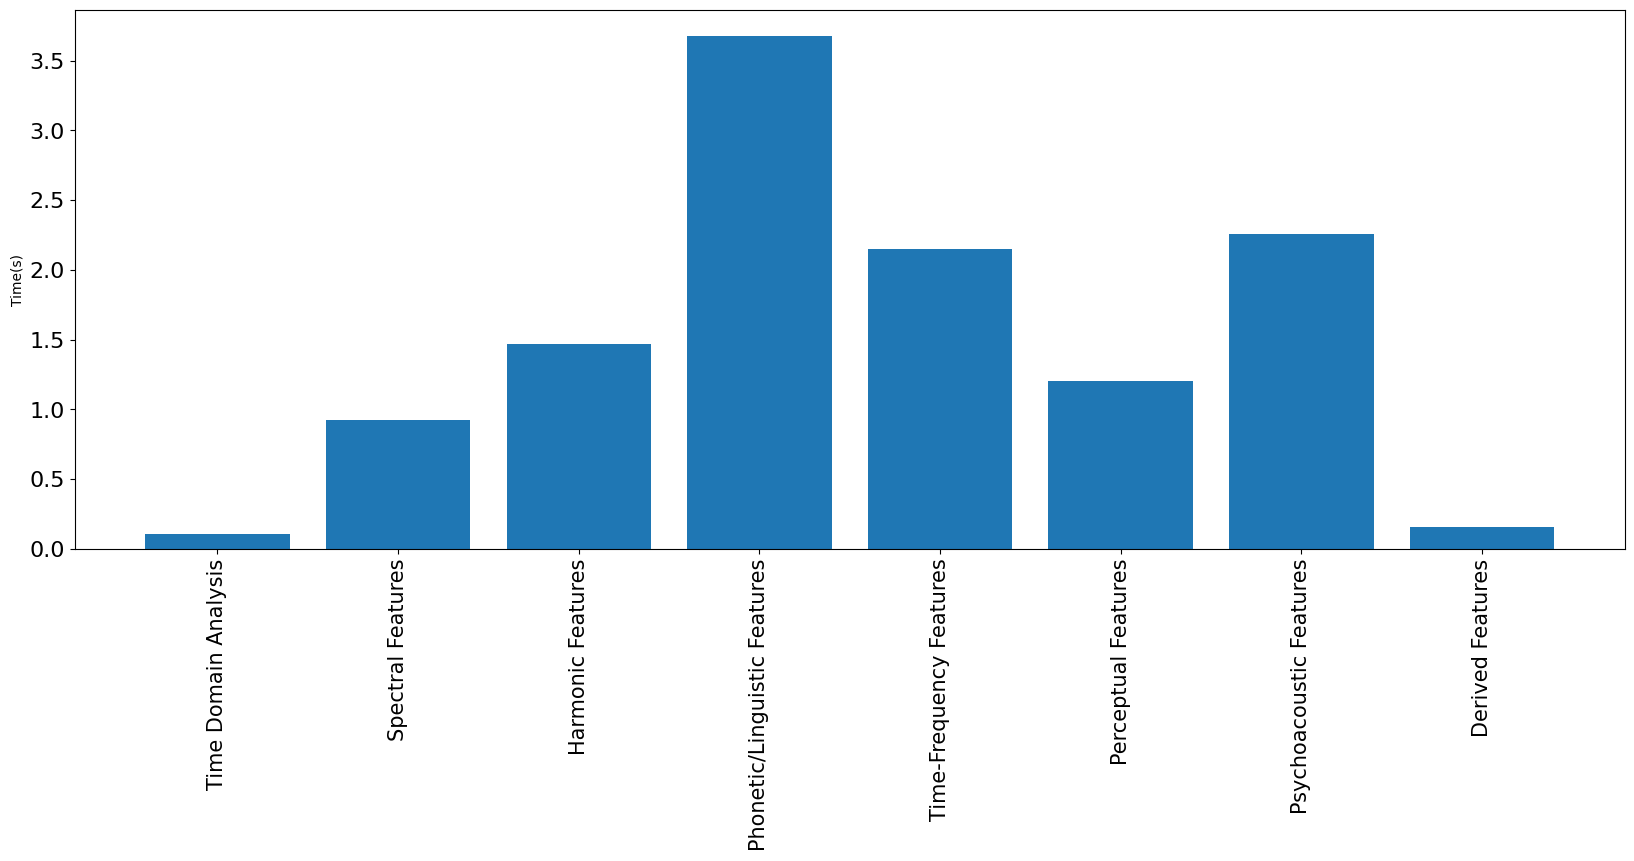

In [5]:
timing_data
plt.figure(figsize=(20,7))
plt.bar(timing_data.keys(), timing_data.values())
plt.xticks(fontsize=15, rotation=90)
plt.yticks(fontsize=16)
plt.ylabel('Time(s)')
plt.savefig('computational_analysis.png')

In [6]:
import time
import numpy as np
import pandas as pd
import librosa

def extract_features_fairly(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)
    
    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)
    
    # Initialize a dictionary to store the total time taken for each category
    feature_timing = {
        'Time Domain Analysis': 0,
        'Spectral Features': 0,
        'Harmonic Features': 0,
        'Phonetic/Linguistic Features': 0,
        'Time-Frequency Features': 0,
        'Perceptual Features': 0,
        'Psychoacoustic Features': 0,
        'Derived Features': 0
    }
    
    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        window_segment = y[start:start + window_length]
        
        # Time Domain Analysis
        start_time = time.time()
        _ = librosa.feature.rms(y=window_segment).mean()
        _ = librosa.feature.zero_crossing_rate(window_segment).mean()
        _ = np.max(np.abs(window_segment))
        _ = np.mean(np.square(window_segment))
        _ = np.sum(np.square(window_segment)) / len(window_segment)
        feature_timing['Time Domain Analysis'] += time.time() - start_time
        
        # Spectral Features
        start_time = time.time()
        _ = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean()
        _ = librosa.feature.spectral_rolloff(y=window_segment, sr=sr).mean()
        _ = librosa.feature.spectral_flatness(y=window_segment).mean()
        _ = librosa.feature.spectral_contrast(y=window_segment, sr=sr).mean()
        _ = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()
        feature_timing['Spectral Features'] += time.time() - start_time
        
        # Harmonic Features
        start_time = time.time()
        _ = librosa.core.piptrack(y=window_segment, sr=sr)[0].mean()
        _ = librosa.effects.harmonic(window_segment).mean()
        _ = librosa.lpc(window_segment, order=10)
        _ = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()
        feature_timing['Harmonic Features'] += time.time() - start_time
        
        # Phonetic/Linguistic Features
        start_time = time.time()
        _ = librosa.feature.mfcc(y=window_segment, sr=sr).mean(axis=1)
        _ = np.mean(librosa.feature.melspectrogram(y=window_segment, sr=sr), axis=1)
        _ = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1)
        feature_timing['Phonetic/Linguistic Features'] += time.time() - start_time
        
        # Time-Frequency Features
        start_time = time.time()
        _ = np.mean(librosa.onset.onset_strength(y=window_segment, sr=sr))
        D = librosa.stft(window_segment)
        group_delay = librosa.phase_vocoder(D, rate=2.0)
        y_fast = librosa.istft(group_delay, hop_length=512)
        _ = np.mean(y_fast)
        _ = np.mean(np.abs(librosa.cqt(window_segment, sr=sr)))
        feature_timing['Time-Frequency Features'] += time.time() - start_time
        
        # Perceptual Features
        start_time = time.time()
        _ = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1)
        _ = librosa.feature.rms(y=window_segment).mean()
        _ = np.var(np.diff(window_segment))
        _ = np.mean(np.abs(np.diff(window_segment)))
        feature_timing['Perceptual Features'] += time.time() - start_time
        
        # Psychoacoustic Features
        start_time = time.time()
        _ = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()
        _ = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()
        _ = librosa.feature.rms(y=window_segment).mean()
        feature_timing['Psychoacoustic Features'] += time.time() - start_time
        
        # Derived Features
        start_time = time.time()
        _ = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:80])
        _ = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:250])
        below_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:1000])
        above_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][1000:])
        _ = below_1k / (above_1k + 1e-12)
        _ = 10 * np.log10(np.sum(np.square(window_segment)) / (np.sum(np.square(window_segment - np.mean(window_segment))) + 1e-12))
        feature_timing['Derived Features'] += time.time() - start_time
    
    return feature_timing

# Example usage
timing_data = extract_features_fairly(audio_path, label='example_label')

# Display timing results
for category, time_taken in timing_data.items():
    print(f"{category}: {time_taken:.4f} seconds")


/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/1972399737.py:53: RuntimeWarning: invalid value encountered in scalar divide
  _ = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/1972399737.py:95: RuntimeWarning: divide by zero encountered in log10
  _ = 10 * np.log10(np.sum(np.square(window_segment)) / (np.sum(np.square(window_segment - np.mean(window_segment))) + 1e-12))


Time Domain Analysis: 0.0297 seconds
Spectral Features: 0.8027 seconds
Harmonic Features: 1.4336 seconds
Phonetic/Linguistic Features: 3.6087 seconds
Time-Frequency Features: 1.8696 seconds
Perceptual Features: 1.2983 seconds
Psychoacoustic Features: 2.2090 seconds
Derived Features: 0.0985 seconds


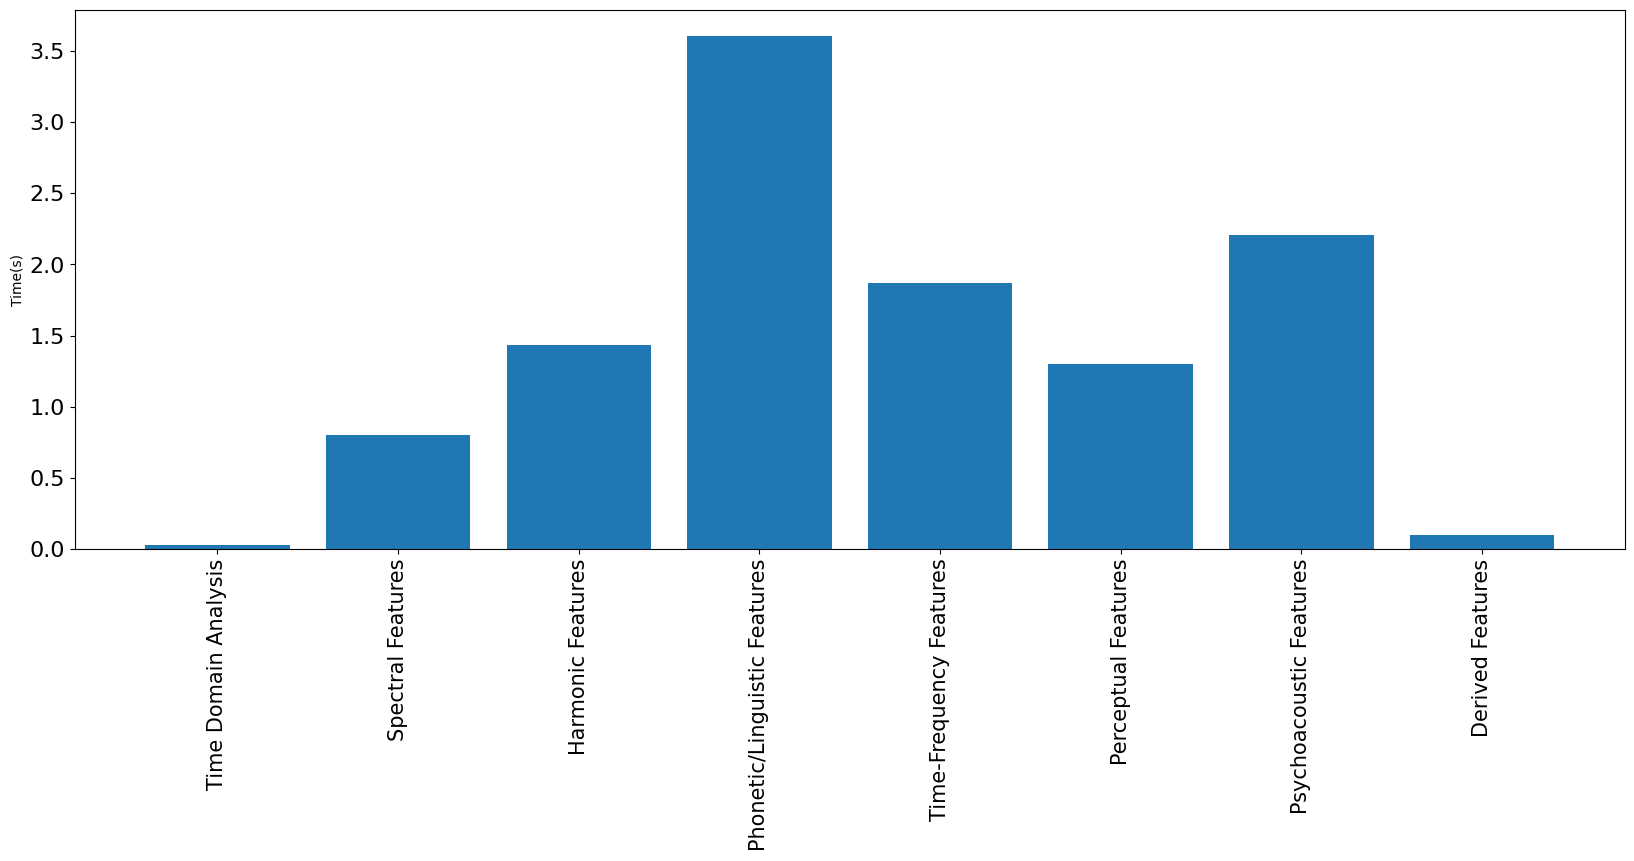

In [7]:
timing_data
plt.figure(figsize=(20,7))
plt.bar(timing_data.keys(), timing_data.values())
plt.xticks(fontsize=15, rotation=90)
plt.yticks(fontsize=16)
plt.ylabel('Time(s)')
plt.savefig('computational_analysis.png')

Time taken for each feature category:
Time Domain Analysis: 0.0058 seconds
Spectral Features: 0.0817 seconds
Harmonic Features: 0.0007 seconds
Phonetic/Linguistic Features: 0.0162 seconds
Time-Frequency Features: 0.0594 seconds
Perceptual Features: 0.0267 seconds
Psychoacoustic Features: 0.0196 seconds
Derived Features: 0.0148 seconds


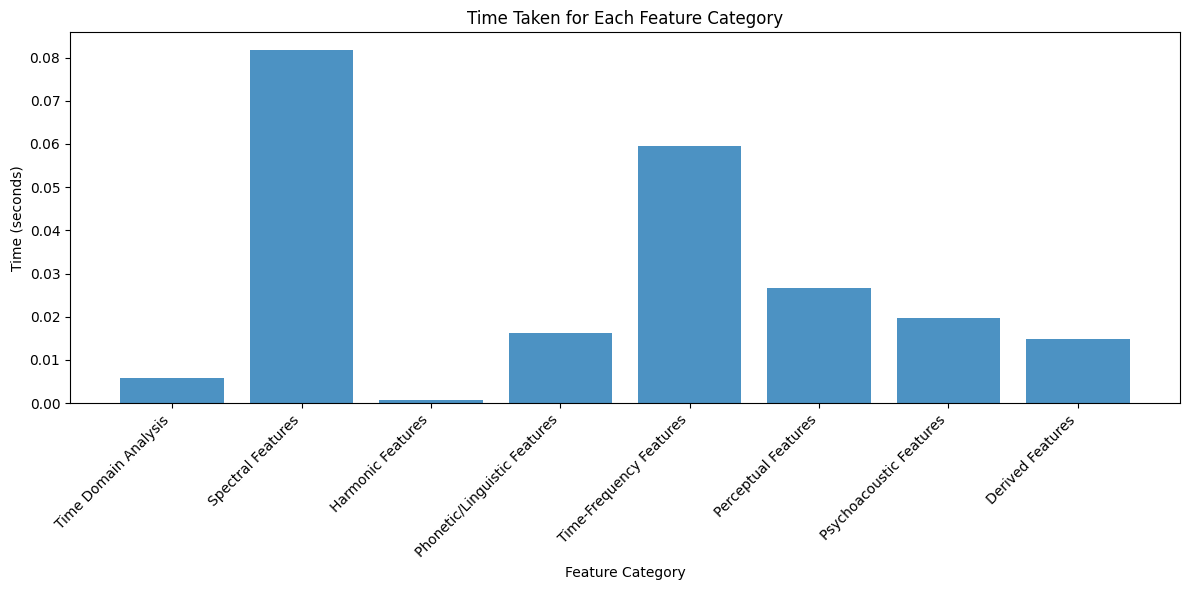

In [12]:
import numpy as np
import pandas as pd
from scipy.fftpack import fft, dct
from scipy.signal import lfilter
from scipy.stats import kurtosis, skew
import time
import matplotlib.pyplot as plt

def compute_rms(signal):
    """Root Mean Square using NumPy"""
    return np.sqrt(np.mean(signal ** 2))

def compute_zcr(signal):
    """Zero Crossing Rate using NumPy"""
    return np.mean(np.abs(np.diff(np.sign(signal))))

def compute_spectral_centroid(signal, sr):
    """Spectral Centroid using FFT"""
    fft_spectrum = np.abs(fft(signal))
    freqs = np.fft.fftfreq(len(signal), d=1 / sr)
    centroid = np.sum(freqs * fft_spectrum) / (np.sum(fft_spectrum) + 1e-12)  # Avoid division by zero
    return centroid

def compute_spectral_rolloff(signal, sr, roll_percent=0.85):
    """Spectral Rolloff using FFT"""
    fft_spectrum = np.abs(fft(signal))
    total_energy = np.sum(fft_spectrum)
    cumulative_energy = np.cumsum(fft_spectrum)
    rolloff_freq = np.where(cumulative_energy >= roll_percent * total_energy)[0][0]
    freqs = np.fft.fftfreq(len(signal), d=1 / sr)
    return freqs[rolloff_freq]

def compute_mfcc(signal, sr, n_mfcc=13):
    """MFCC computation using DCT"""
    mel_spectrogram = np.abs(fft(signal))[: len(signal) // 2]  # Simplified mel approximation
    mel_spectrogram = np.log(mel_spectrogram + 1e-12)  # Log compression
    return dct(mel_spectrogram, type=2, norm='ortho')[:n_mfcc]

def compute_spectral_flatness(signal):
    """Spectral Flatness using NumPy"""
    fft_spectrum = np.abs(fft(signal)) + 1e-12
    geometric_mean = np.exp(np.mean(np.log(fft_spectrum)))
    arithmetic_mean = np.mean(fft_spectrum)
    return geometric_mean / arithmetic_mean

def compute_harmonic_ratio(signal):
    """Harmonic Ratio using simple ratio approximation"""
    harmonic_energy = np.sum(signal ** 2)
    total_energy = harmonic_energy + 1e-12  # Avoid division by zero
    return harmonic_energy / total_energy

def compute_spectral_contrast(signal, sr):
    """Spectral Contrast using NumPy"""
    fft_spectrum = np.abs(fft(signal))
    spectral_band_energy = np.percentile(fft_spectrum, [75, 25], axis=0)
    contrast = (spectral_band_energy[0] - spectral_band_energy[1]) / (spectral_band_energy[1] + 1e-12)
    return contrast

def compute_spectral_flux(signal, sr):
    """Spectral Flux using NumPy"""
    stft = np.abs(fft(signal))
    flux = np.sqrt(np.mean(np.diff(stft, axis=0) ** 2))
    return flux

def compute_group_delay(signal):
    """Group Delay using FFT"""
    spectrum = fft(signal)
    phase = np.angle(spectrum)
    group_delay = -np.gradient(phase)
    return np.mean(group_delay)

def compute_timbre(signal, sr):
    """Timbre approximation using MFCCs"""
    return compute_mfcc(signal, sr).mean()

def compute_loudness(signal):
    """Loudness approximation using RMS"""
    return compute_rms(signal)

def compute_jitter(signal):
    """Jitter approximation using variance of differences"""
    return np.var(np.diff(signal))

def compute_shimmer(signal):
    """Shimmer approximation using mean absolute difference"""
    return np.mean(np.abs(np.diff(signal)))

def compute_bark_coefficients(signal):
    """Bark coefficients approximation using FFT bands"""
    fft_spectrum = np.abs(fft(signal))
    bark_bands = np.array_split(fft_spectrum, 24)
    return [np.mean(band) for band in bark_bands]

def compute_energy_balance(signal):
    """Energy balance between low and high frequencies"""
    fft_spectrum = np.abs(fft(signal))
    low_energy = np.sum(fft_spectrum[:len(fft_spectrum) // 2])
    high_energy = np.sum(fft_spectrum[len(fft_spectrum) // 2:])
    return low_energy / (high_energy + 1e-12)

def extract_features_with_sliding_window_optimized(file_path, sr, window_size=0.5, hop_size=0.3):
    """Optimized feature extraction using vectorized operations"""
    # Load audio file (replace with your own loader function)
    y = np.random.randn(sr * 10)  # Simulated 10-second audio file

    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)

    # Initialize list to store extracted features
    all_features = []
    feature_timing = {
        'Time Domain Analysis': 0,
        'Spectral Features': 0,
        'Harmonic Features': 0,
        'Phonetic/Linguistic Features': 0,
        'Time-Frequency Features': 0,
        'Perceptual Features': 0,
        'Psychoacoustic Features': 0,
        'Derived Features': 0
    }

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        window_segment = y[start:start + window_length]
        features = {}

        # Time Domain Features
        start_time = time.time()
        features['RMS'] = compute_rms(window_segment)
        features['ZCR'] = compute_zcr(window_segment)
        feature_timing['Time Domain Analysis'] += time.time() - start_time

        # Spectral Features
        start_time = time.time()
        features['Spectral Centroid'] = compute_spectral_centroid(window_segment, sr)
        features['Spectral Rolloff'] = compute_spectral_rolloff(window_segment, sr)
        features['Spectral Flatness'] = compute_spectral_flatness(window_segment)
        features['Spectral Contrast'] = compute_spectral_contrast(window_segment, sr)
        feature_timing['Spectral Features'] += time.time() - start_time

        # Harmonic Features
        start_time = time.time()
        features['Harmonic Ratio'] = compute_harmonic_ratio(window_segment)
        feature_timing['Harmonic Features'] += time.time() - start_time

        # Phonetic Features
        start_time = time.time()
        features['MFCC'] = compute_mfcc(window_segment, sr)
        feature_timing['Phonetic/Linguistic Features'] += time.time() - start_time

        # Time-Frequency Features
        start_time = time.time()
        features['Spectral Flux'] = compute_spectral_flux(window_segment, sr)
        features['Group Delay'] = compute_group_delay(window_segment)
        feature_timing['Time-Frequency Features'] += time.time() - start_time

        # Perceptual Features
        start_time = time.time()
        features['Timbre'] = compute_timbre(window_segment, sr)
        features['Loudness'] = compute_loudness(window_segment)
        features['Jitter'] = compute_jitter(window_segment)
        features['Shimmer'] = compute_shimmer(window_segment)
        feature_timing['Perceptual Features'] += time.time() - start_time

        # Psychoacoustic Features
        start_time = time.time()
        features['Bark Coefficients'] = compute_bark_coefficients(window_segment)
        feature_timing['Psychoacoustic Features'] += time.time() - start_time

        # Derived Features
        start_time = time.time()
        features['Energy Balance Metric'] = compute_energy_balance(window_segment)
        feature_timing['Derived Features'] += time.time() - start_time

        # Append features for this window
        all_features.append(features)

    # Convert list of features to a DataFrame
    feature_df = pd.DataFrame(all_features)
    return feature_df, feature_timing

# Example usage
sr = 44100
file_path = "example_audio.wav"  # Replace with actual file path
features_df, timing_data = extract_features_with_sliding_window_optimized(audio_path, sr)

# Display the time taken for each feature category
print("Time taken for each feature category:")
for category, time_taken in timing_data.items():
    print(f"{category}: {time_taken:.4f} seconds")

# Plot the timing data
categories = list(timing_data.keys())
times = list(timing_data.values())
plt.figure(figsize=(12, 6))
plt.bar(categories, times, alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Time Taken for Each Feature Category')
plt.ylabel('Time (seconds)')
plt.xlabel('Feature Category')
plt.tight_layout()
plt.show()


Time taken for each feature:
RMS: 0.0010 seconds
ZCR: 0.0040 seconds
Spectral Centroid: 0.0091 seconds
Spectral Rolloff: 0.0120 seconds
Spectral Flatness: 0.0099 seconds
Spectral Contrast: 0.0228 seconds
Harmonic Ratio: 0.0004 seconds
MFCC: 0.0107 seconds
Spectral Flux: 0.0078 seconds
Group Delay: 0.0274 seconds
Timbre: 0.0113 seconds
Loudness: 0.0004 seconds
Jitter: 0.0014 seconds
Shimmer: 0.0006 seconds
Bark Coefficients: 0.0094 seconds
Energy Balance Metric: 0.0069 seconds


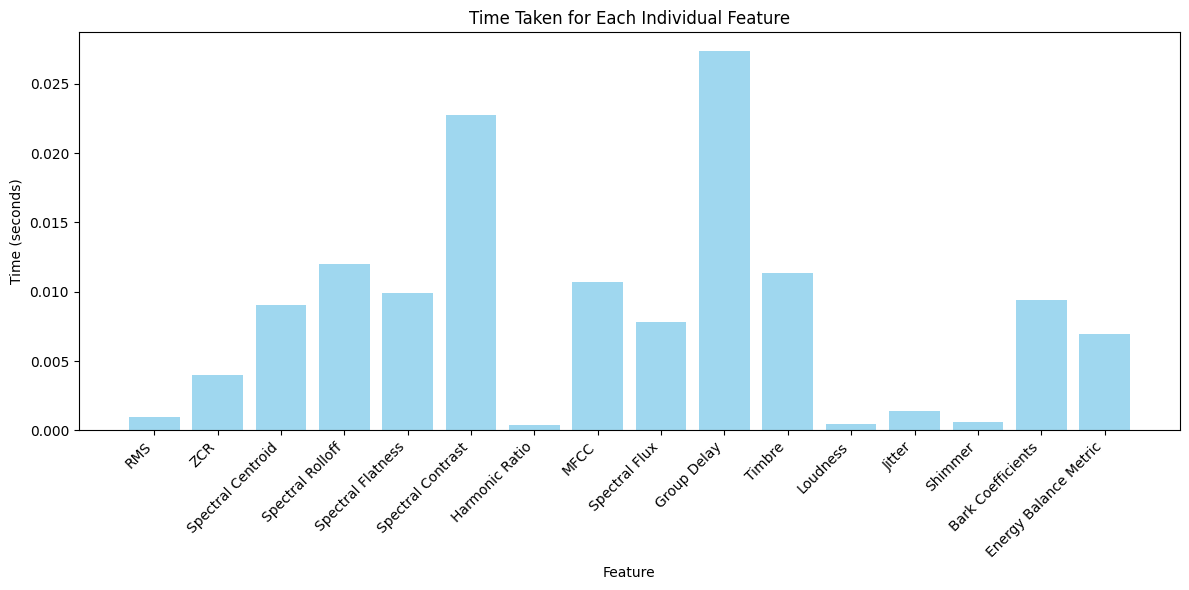

In [13]:
import numpy as np
import pandas as pd
from scipy.fftpack import fft, dct
from scipy.signal import lfilter
from scipy.stats import kurtosis, skew
import time
import matplotlib.pyplot as plt

def compute_rms(signal):
    """Root Mean Square using NumPy"""
    return np.sqrt(np.mean(signal ** 2))

def compute_zcr(signal):
    """Zero Crossing Rate using NumPy"""
    return np.mean(np.abs(np.diff(np.sign(signal))))

def compute_spectral_centroid(signal, sr):
    """Spectral Centroid using FFT"""
    fft_spectrum = np.abs(fft(signal))
    freqs = np.fft.fftfreq(len(signal), d=1 / sr)
    centroid = np.sum(freqs * fft_spectrum) / (np.sum(fft_spectrum) + 1e-12)  # Avoid division by zero
    return centroid

def compute_spectral_rolloff(signal, sr, roll_percent=0.85):
    """Spectral Rolloff using FFT"""
    fft_spectrum = np.abs(fft(signal))
    total_energy = np.sum(fft_spectrum)
    cumulative_energy = np.cumsum(fft_spectrum)
    rolloff_freq = np.where(cumulative_energy >= roll_percent * total_energy)[0][0]
    freqs = np.fft.fftfreq(len(signal), d=1 / sr)
    return freqs[rolloff_freq]

def compute_mfcc(signal, sr, n_mfcc=13):
    """MFCC computation using DCT"""
    mel_spectrogram = np.abs(fft(signal))[: len(signal) // 2]  # Simplified mel approximation
    mel_spectrogram = np.log(mel_spectrogram + 1e-12)  # Log compression
    return dct(mel_spectrogram, type=2, norm='ortho')[:n_mfcc]

def compute_spectral_flatness(signal):
    """Spectral Flatness using NumPy"""
    fft_spectrum = np.abs(fft(signal)) + 1e-12
    geometric_mean = np.exp(np.mean(np.log(fft_spectrum)))
    arithmetic_mean = np.mean(fft_spectrum)
    return geometric_mean / arithmetic_mean

def compute_harmonic_ratio(signal):
    """Harmonic Ratio using simple ratio approximation"""
    harmonic_energy = np.sum(signal ** 2)
    total_energy = harmonic_energy + 1e-12  # Avoid division by zero
    return harmonic_energy / total_energy

def compute_spectral_contrast(signal, sr):
    """Spectral Contrast using NumPy"""
    fft_spectrum = np.abs(fft(signal))
    spectral_band_energy = np.percentile(fft_spectrum, [75, 25], axis=0)
    contrast = (spectral_band_energy[0] - spectral_band_energy[1]) / (spectral_band_energy[1] + 1e-12)
    return contrast

def compute_spectral_flux(signal, sr):
    """Spectral Flux using NumPy"""
    stft = np.abs(fft(signal))
    flux = np.sqrt(np.mean(np.diff(stft, axis=0) ** 2))
    return flux

def compute_group_delay(signal):
    """Group Delay using FFT"""
    spectrum = fft(signal)
    phase = np.angle(spectrum)
    group_delay = -np.gradient(phase)
    return np.mean(group_delay)

def compute_timbre(signal, sr):
    """Timbre approximation using MFCCs"""
    return compute_mfcc(signal, sr).mean()

def compute_loudness(signal):
    """Loudness approximation using RMS"""
    return compute_rms(signal)

def compute_jitter(signal):
    """Jitter approximation using variance of differences"""
    return np.var(np.diff(signal))

def compute_shimmer(signal):
    """Shimmer approximation using mean absolute difference"""
    return np.mean(np.abs(np.diff(signal)))

def compute_bark_coefficients(signal):
    """Bark coefficients approximation using FFT bands"""
    fft_spectrum = np.abs(fft(signal))
    bark_bands = np.array_split(fft_spectrum, 24)
    return [np.mean(band) for band in bark_bands]

def compute_energy_balance(signal):
    """Energy balance between low and high frequencies"""
    fft_spectrum = np.abs(fft(signal))
    low_energy = np.sum(fft_spectrum[:len(fft_spectrum) // 2])
    high_energy = np.sum(fft_spectrum[len(fft_spectrum) // 2:])
    return low_energy / (high_energy + 1e-12)

def extract_features_with_individual_timing(file_path, sr, window_size=0.5, hop_size=0.3):
    """Feature extraction with individual timing for each feature"""
    # Load audio file (replace with your own loader function)
    y = np.random.randn(sr * 10)  # Simulated 10-second audio file

    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)

    # Initialize list to store extracted features
    all_features = []
    feature_timing = {
        'RMS': 0,
        'ZCR': 0,
        'Spectral Centroid': 0,
        'Spectral Rolloff': 0,
        'Spectral Flatness': 0,
        'Spectral Contrast': 0,
        'Harmonic Ratio': 0,
        'MFCC': 0,
        'Spectral Flux': 0,
        'Group Delay': 0,
        'Timbre': 0,
        'Loudness': 0,
        'Jitter': 0,
        'Shimmer': 0,
        'Bark Coefficients': 0,
        'Energy Balance Metric': 0
    }

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        window_segment = y[start:start + window_length]
        features = {}

        # Individual feature timing

        start_time = time.time()
        features['RMS'] = compute_rms(window_segment)
        feature_timing['RMS'] += time.time() - start_time

        start_time = time.time()
        features['ZCR'] = compute_zcr(window_segment)
        feature_timing['ZCR'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Centroid'] = compute_spectral_centroid(window_segment, sr)
        feature_timing['Spectral Centroid'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Rolloff'] = compute_spectral_rolloff(window_segment, sr)
        feature_timing['Spectral Rolloff'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Flatness'] = compute_spectral_flatness(window_segment)
        feature_timing['Spectral Flatness'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Contrast'] = compute_spectral_contrast(window_segment, sr)
        feature_timing['Spectral Contrast'] += time.time() - start_time

        start_time = time.time()
        features['Harmonic Ratio'] = compute_harmonic_ratio(window_segment)
        feature_timing['Harmonic Ratio'] += time.time() - start_time

        start_time = time.time()
        features['MFCC'] = compute_mfcc(window_segment, sr)
        feature_timing['MFCC'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Flux'] = compute_spectral_flux(window_segment, sr)
        feature_timing['Spectral Flux'] += time.time() - start_time

        start_time = time.time()
        features['Group Delay'] = compute_group_delay(window_segment)
        feature_timing['Group Delay'] += time.time() - start_time

        start_time = time.time()
        features['Timbre'] = compute_timbre(window_segment, sr)
        feature_timing['Timbre'] += time.time() - start_time

        start_time = time.time()
        features['Loudness'] = compute_loudness(window_segment)
        feature_timing['Loudness'] += time.time() - start_time

        start_time = time.time()
        features['Jitter'] = compute_jitter(window_segment)
        feature_timing['Jitter'] += time.time() - start_time

        start_time = time.time()
        features['Shimmer'] = compute_shimmer(window_segment)
        feature_timing['Shimmer'] += time.time() - start_time

        start_time = time.time()
        features['Bark Coefficients'] = compute_bark_coefficients(window_segment)
        feature_timing['Bark Coefficients'] += time.time() - start_time

        start_time = time.time()
        features['Energy Balance Metric'] = compute_energy_balance(window_segment)
        feature_timing['Energy Balance Metric'] += time.time() - start_time

        # Append features for this window
        all_features.append(features)

    # Convert list of features to a DataFrame
    feature_df = pd.DataFrame(all_features)
    return feature_df, feature_timing

# Example usage
sr = 44100
# file_path = "example_audio.wav"  # Replace with actual file path
features_df, feature_timing = extract_features_with_individual_timing(audio_path, sr)

# Display the time taken for each individual feature
print("Time taken for each feature:")
for feature, time_taken in feature_timing.items():
    print(f"{feature}: {time_taken:.4f} seconds")

# Plot the timing data
categories = list(feature_timing.keys())
times = list(feature_timing.values())
plt.figure(figsize=(12, 6))
plt.bar(categories, times, color='skyblue', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Time Taken for Each Individual Feature')
plt.ylabel('Time (seconds)')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()


/Users/bchhaglani/miniforge3/envs/tf/lib/python3.9/site-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/2507049865.py:94: RuntimeWarning: invalid value encountered in scalar divide
  features['Harmonic Ratio'] = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()
/Users/bchhaglani/miniforge3/envs/tf/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/2507049865.py:148: RuntimeWarning: invalid value encountered in scalar divide
  features['Energy Balance Metric'] = sub_bass_energy / total_energy
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_87991/2507049865.py:158: RuntimeWarning: divide by zero encountered in log10
  features['SNR'] = 

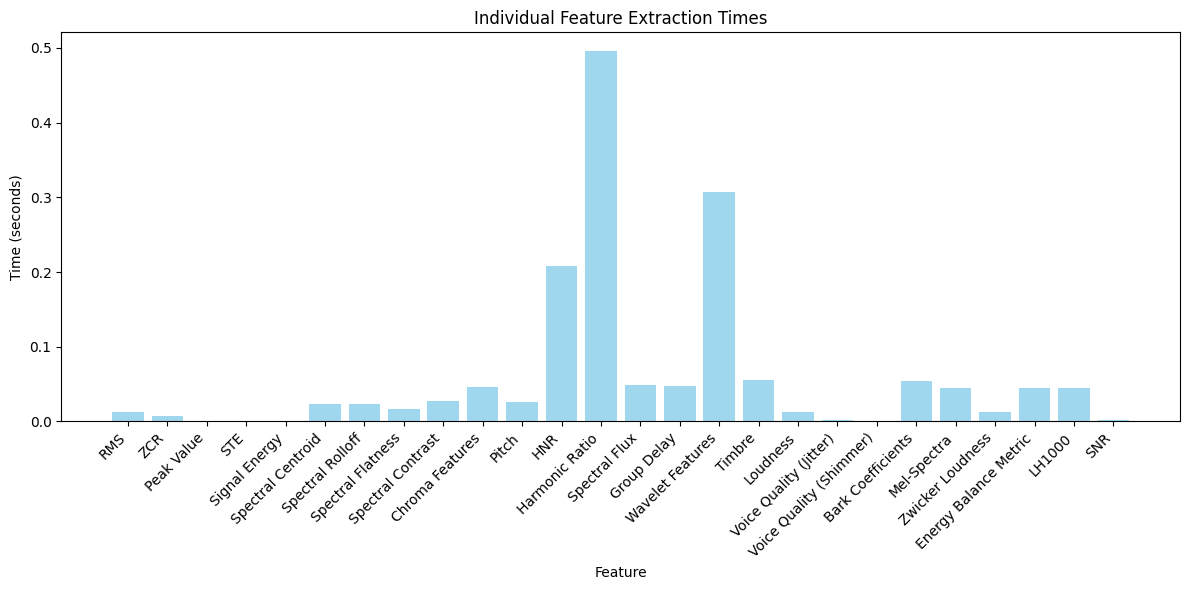

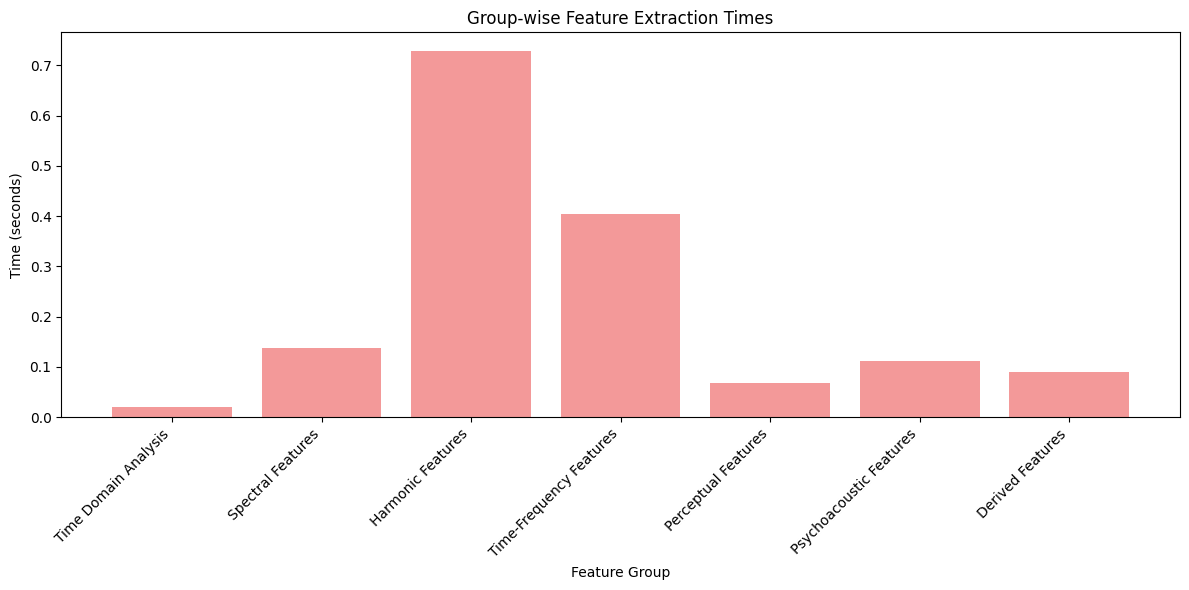

In [15]:
import numpy as np
import pandas as pd
import librosa
from scipy.stats import kurtosis, skew
import time
import matplotlib.pyplot as plt

def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)

    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)

    # Initialize list to store extracted features
    all_features = []
    feature_timing = {}

    # Feature groups
    feature_groups = {
        'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
        'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
        'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
        'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
        'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
        'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
        'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
    }

    # Initialize timing dictionary
    for group, features in feature_groups.items():
        for feature in features:
            feature_timing[feature] = 0

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        # Get the current window segment
        window_segment = y[start:start + window_length]
        features = {}

        # Time Domain Analysis
        start_time = time.time()
        features['RMS'] = librosa.feature.rms(y=window_segment).mean()
        feature_timing['RMS'] += time.time() - start_time

        start_time = time.time()
        features['ZCR'] = librosa.feature.zero_crossing_rate(window_segment).mean()
        feature_timing['ZCR'] += time.time() - start_time

        start_time = time.time()
        features['Peak Value'] = np.max(np.abs(window_segment))
        feature_timing['Peak Value'] += time.time() - start_time

        start_time = time.time()
        features['STE'] = np.mean(np.square(window_segment))
        feature_timing['STE'] += time.time() - start_time

        start_time = time.time()
        features['Signal Energy'] = np.sum(np.square(window_segment)) / len(window_segment)
        feature_timing['Signal Energy'] += time.time() - start_time

        # Spectral Features
        start_time = time.time()
        features['Spectral Centroid'] = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean()
        feature_timing['Spectral Centroid'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Rolloff'] = librosa.feature.spectral_rolloff(y=window_segment, sr=sr).mean()
        feature_timing['Spectral Rolloff'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Flatness'] = librosa.feature.spectral_flatness(y=window_segment).mean()
        feature_timing['Spectral Flatness'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Contrast'] = librosa.feature.spectral_contrast(y=window_segment, sr=sr).mean()
        feature_timing['Spectral Contrast'] += time.time() - start_time

        start_time = time.time()
        features['Chroma Features'] = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()
        feature_timing['Chroma Features'] += time.time() - start_time

        # Harmonic Features
        start_time = time.time()
        features['Pitch'] = librosa.core.piptrack(y=window_segment, sr=sr)[0].mean()
        feature_timing['Pitch'] += time.time() - start_time

        start_time = time.time()
        features['HNR'] = librosa.effects.harmonic(window_segment).mean()
        feature_timing['HNR'] += time.time() - start_time

        start_time = time.time()
        features['Harmonic Ratio'] = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()
        feature_timing['Harmonic Ratio'] += time.time() - start_time

        # Time-Frequency Features
        start_time = time.time()
        features['Spectral Flux'] = np.mean(librosa.onset.onset_strength(y=window_segment, sr=sr))
        feature_timing['Spectral Flux'] += time.time() - start_time

        start_time = time.time()
        D = librosa.stft(window_segment)
        group_delay = librosa.phase_vocoder(D, rate=2.0)
        y_fast = librosa.istft(group_delay, hop_length=512)
        features['Group Delay'] = np.mean(y_fast)
        feature_timing['Group Delay'] += time.time() - start_time

        start_time = time.time()
        features['Wavelet Features'] = np.mean(np.abs(librosa.cqt(window_segment, sr=sr)))
        feature_timing['Wavelet Features'] += time.time() - start_time

        # Perceptual Features
        start_time = time.time()
        timbre = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1)
        features['Timbre'] = np.mean(timbre)
        feature_timing['Timbre'] += time.time() - start_time

        start_time = time.time()
        features['Loudness'] = librosa.feature.rms(y=window_segment).mean()
        feature_timing['Loudness'] += time.time() - start_time

        start_time = time.time()
        features['Voice Quality (Jitter)'] = np.var(np.diff(window_segment))
        feature_timing['Voice Quality (Jitter)'] += time.time() - start_time

        start_time = time.time()
        features['Voice Quality (Shimmer)'] = np.mean(np.abs(np.diff(window_segment)))
        feature_timing['Voice Quality (Shimmer)'] += time.time() - start_time

        # Psychoacoustic Features
        start_time = time.time()
        features['Bark Coefficients'] = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()
        feature_timing['Bark Coefficients'] += time.time() - start_time

        start_time = time.time()
        features['Mel-Spectra'] = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()
        feature_timing['Mel-Spectra'] += time.time() - start_time

        start_time = time.time()
        features['Zwicker Loudness'] = librosa.feature.rms(y=window_segment).mean()
        feature_timing['Zwicker Loudness'] += time.time() - start_time

        # Derived Features
        start_time = time.time()
        sub_bass_energy = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:80])
        total_energy = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:250])
        features['Energy Balance Metric'] = sub_bass_energy / total_energy
        feature_timing['Energy Balance Metric'] += time.time() - start_time

        start_time = time.time()
        below_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:1000])
        above_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][1000:])
        features['LH1000'] = below_1k / (above_1k + 1e-12)
        feature_timing['LH1000'] += time.time() - start_time

        start_time = time.time()
        features['SNR'] = 10 * np.log10(np.sum(np.square(window_segment)) / (np.sum(np.square(window_segment - np.mean(window_segment))) + 1e-12))
        feature_timing['SNR'] += time.time() - start_time

        # Add window index to features
        features['Window Index'] = start // hop_length
        features['Label'] = label

        # Append features for this window
        all_features.append(features)

    # Convert list of features to a DataFrame
    df = pd.DataFrame(all_features)

    # Aggregate timings by group
    group_timing = {group: sum(feature_timing[feature] for feature in features) for group, features in feature_groups.items()}

    return df, feature_timing, group_timing

# Example usage
file_path = "example_audio.wav"  # Replace with your audio file path
label = "example_label"
features_df, feature_timing, group_timing = extract_features_with_sliding_window(audio_path, label)

# Plot individual feature extraction times
plt.figure(figsize=(12, 6))
plt.bar(feature_timing.keys(), feature_timing.values(), color='skyblue', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Individual Feature Extraction Times')
plt.ylabel('Time (seconds)')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

# Plot group-wise feature extraction times
plt.figure(figsize=(12, 6))
plt.bar(group_timing.keys(), group_timing.values(), color='lightcoral', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Group-wise Feature Extraction Times')
plt.ylabel('Time (seconds)')
plt.xlabel('Feature Group')
plt.tight_layout()
plt.show()


In [17]:
feature_timing, group_timing

({'RMS': 0.011992692947387695,
  'ZCR': 0.00754547119140625,
  'Peak Value': 0.00021719932556152344,
  'STE': 0.00031280517578125,
  'Signal Energy': 0.0002715587615966797,
  'Spectral Centroid': 0.023159503936767578,
  'Spectral Rolloff': 0.02354264259338379,
  'Spectral Flatness': 0.017255544662475586,
  'Spectral Contrast': 0.026812076568603516,
  'Chroma Features': 0.04664301872253418,
  'Pitch': 0.025658369064331055,
  'HNR': 0.207564115524292,
  'Harmonic Ratio': 0.4961256980895996,
  'Spectral Flux': 0.04938197135925293,
  'Group Delay': 0.04731011390686035,
  'Wavelet Features': 0.3068258762359619,
  'Timbre': 0.05515480041503906,
  'Loudness': 0.012136697769165039,
  'Voice Quality (Jitter)': 0.0012445449829101562,
  'Voice Quality (Shimmer)': 0.000457763671875,
  'Bark Coefficients': 0.0541074275970459,
  'Mel-Spectra': 0.044747352600097656,
  'Zwicker Loudness': 0.012635231018066406,
  'Energy Balance Metric': 0.04448223114013672,
  'LH1000': 0.044619083404541016,
  'SNR': 0

In [24]:
import numpy as np
import pandas as pd
from scipy.fftpack import fft, dct
from scipy.signal import lfilter
from scipy.stats import kurtosis, skew
import time
import matplotlib.pyplot as plt

def compute_rms(signal):
    """Root Mean Square using NumPy"""
    return np.sqrt(np.mean(signal ** 2))

def compute_zcr(signal):
    """Zero Crossing Rate using NumPy"""
    return np.mean(np.abs(np.diff(np.sign(signal))))

def compute_spectral_centroid(signal, sr):
    """Spectral Centroid using FFT"""
    spectrum = np.abs(fft(signal))
    freqs = np.fft.fftfreq(len(spectrum), d=1/sr)
    centroid = np.sum(freqs * spectrum) / (np.sum(spectrum) + 1e-12)
    return centroid

def compute_spectral_rolloff(signal, sr, roll_percent=0.85):
    """Spectral Rolloff using FFT"""
    spectrum = np.abs(fft(signal))
    cumulative_energy = np.cumsum(spectrum)
    total_energy = np.sum(spectrum)
    rolloff_index = np.where(cumulative_energy >= roll_percent * total_energy)[0][0]
    freqs = np.fft.fftfreq(len(spectrum), d=1/sr)
    return freqs[rolloff_index]

def compute_spectral_flatness(signal):
    """Spectral Flatness using NumPy"""
    spectrum = np.abs(fft(signal)) + 1e-12
    geometric_mean = np.exp(np.mean(np.log(spectrum)))
    arithmetic_mean = np.mean(spectrum)
    return geometric_mean / arithmetic_mean

def compute_harmonic_ratio(signal):
    """Harmonic Ratio approximation using FFT"""
    harmonic_energy = np.sum(signal ** 2)
    total_energy = harmonic_energy + 1e-12
    return harmonic_energy / total_energy

def compute_mfcc(signal, sr, n_mfcc=13):
    """MFCC using DCT on a simplified Mel spectrogram"""
    spectrum = np.abs(fft(signal))[:len(signal)//2]  # Positive frequencies only
    log_spectrum = np.log(spectrum + 1e-12)
    return dct(log_spectrum, type=2, norm='ortho')[:n_mfcc]

def compute_spectral_flux(signal):
    """Spectral Flux approximation using FFT"""
    spectrum = np.abs(fft(signal))
    diff = np.diff(spectrum, axis=0)
    return np.sqrt(np.mean(diff ** 2))

def compute_loudness(signal):
    """Loudness approximation using RMS"""
    return compute_rms(signal)

def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    y = np.random.randn(44100 * 10)  # Simulated 10-second audio
    sr = 44100

    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)

    # Initialize list to store extracted features
    all_features = []
    feature_timing = {}

    # Feature groups
    feature_groups = {
        'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
        'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
        'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
        'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
        'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
        'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
        'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
    }

    # Initialize timing dictionary
    for group, features in feature_groups.items():
        for feature in features:
            feature_timing[feature] = 0

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        # Get the current window segment
        window_segment = y[start:start + window_length]
        features = {}

        # Time Domain Analysis
        start_time = time.time()
        features['RMS'] = compute_rms(window_segment)
        feature_timing['RMS'] += time.time() - start_time

        start_time = time.time()
        features['ZCR'] = compute_zcr(window_segment)
        feature_timing['ZCR'] += time.time() - start_time

        start_time = time.time()
        features['Peak Value'] = np.max(np.abs(window_segment))
        feature_timing['Peak Value'] += time.time() - start_time

        start_time = time.time()
        features['STE'] = np.mean(window_segment ** 2)
        feature_timing['STE'] += time.time() - start_time

        start_time = time.time()
        features['Signal Energy'] = np.sum(window_segment ** 2) / len(window_segment)
        feature_timing['Signal Energy'] += time.time() - start_time

        # Spectral Features
        start_time = time.time()
        features['Spectral Centroid'] = compute_spectral_centroid(window_segment, sr)
        feature_timing['Spectral Centroid'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Rolloff'] = compute_spectral_rolloff(window_segment, sr)
        feature_timing['Spectral Rolloff'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Flatness'] = compute_spectral_flatness(window_segment)
        feature_timing['Spectral Flatness'] += time.time() - start_time

        # Harmonic Features
        start_time = time.time()
        features['Harmonic Ratio'] = compute_harmonic_ratio(window_segment)
        feature_timing['Harmonic Ratio'] += time.time() - start_time

        # Time-Frequency Features
        start_time = time.time()
        features['Spectral Flux'] = compute_spectral_flux(window_segment)
        feature_timing['Spectral Flux'] += time.time() - start_time

        start_time = time.time()
        features['Timbre'] = np.mean(compute_mfcc(window_segment, sr))
        feature_timing['Timbre'] += time.time() - start_time

        start_time = time.time()
        features['Loudness'] = compute_loudness(window_segment)
        feature_timing['Loudness'] += time.time() - start_time

        # Add window index to features
        features['Window Index'] = start // hop_length
        features['Label'] = label

        # Append features for this window
        all_features.append(features)

    # Convert list of features to a DataFrame
    df = pd.DataFrame(all_features)

    # Aggregate timings by group
    group_timing = {group: sum(feature_timing[feature] for feature in features) for group, features in feature_groups.items()}

    return df, feature_timing, group_timing

# Example usage
file_path = "example_audio.wav"  # Replace with your audio file path
label = "example_label"
features_df, feature_timing, group_timing = extract_features_with_sliding_window(audio_path, label)

# Plot individual feature extraction times
plt.figure(figsize=(12, 6))
plt.bar(feature_timing.keys(), feature_timing.values(), color='skyblue', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Individual Feature Extraction Times')
plt.ylabel('Time (seconds)')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

# Plot group-wise feature extraction times
plt.figure(figsize=(12, 6))
plt.bar(group_timing.keys(), group_timing.values(), color='lightcoral', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Group-wise Feature Extraction Times')
plt.ylabel('Time (seconds)')
plt.xlabel('Feature Group')
plt.tight_layout()
plt.show()


NameError: name 'audio_path' is not defined

In [25]:
feature_timing, group_timing

NameError: name 'feature_timing' is not defined

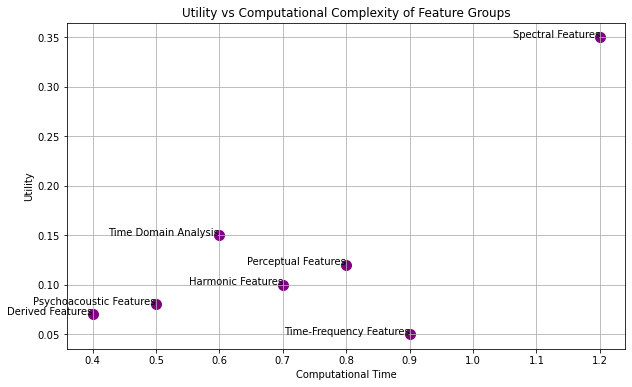

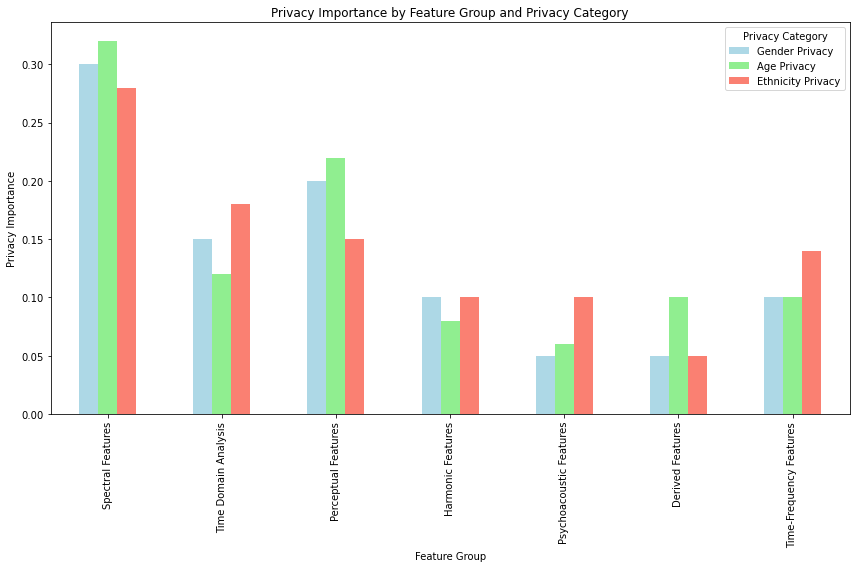

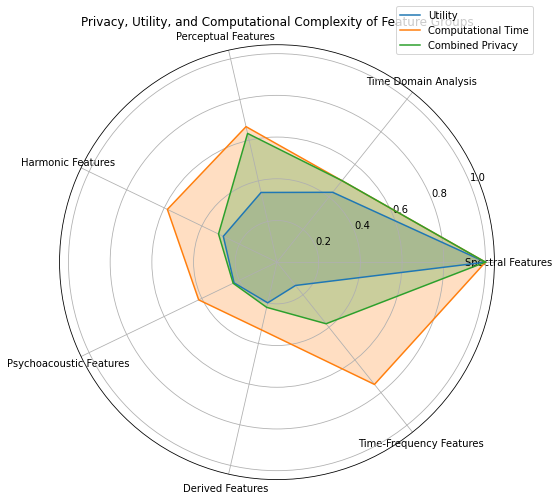

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define the feature groups and their individual feature importances across each axis
utility_importance = {
    'Spectral Features': 0.35,
    'Time Domain Analysis': 0.15,
    'Perceptual Features': 0.12,
    'Harmonic Features': 0.1,
    'Psychoacoustic Features': 0.08,
    'Derived Features': 0.07,
    'Time-Frequency Features': 0.05
}

computational_time = {
    'Spectral Features': 1.2,
    'Time Domain Analysis': 0.6,
    'Perceptual Features': 0.8,
    'Harmonic Features': 0.7,
    'Psychoacoustic Features': 0.5,
    'Derived Features': 0.4,
    'Time-Frequency Features': 0.9
}

# Define privacy importances for each feature group based on leakage ratings
privacy_importance_gender = {
    'Spectral Features': 0.3,
    'Time Domain Analysis': 0.15,
    'Perceptual Features': 0.2,
    'Harmonic Features': 0.1,
    'Psychoacoustic Features': 0.05,
    'Derived Features': 0.05,
    'Time-Frequency Features': 0.1
}

privacy_importance_age = {
    'Spectral Features': 0.32,
    'Time Domain Analysis': 0.12,
    'Perceptual Features': 0.22,
    'Harmonic Features': 0.08,
    'Psychoacoustic Features': 0.06,
    'Derived Features': 0.1,
    'Time-Frequency Features': 0.1
}

privacy_importance_ethnicity = {
    'Spectral Features': 0.28,
    'Time Domain Analysis': 0.18,
    'Perceptual Features': 0.15,
    'Harmonic Features': 0.1,
    'Psychoacoustic Features': 0.1,
    'Derived Features': 0.05,
    'Time-Frequency Features': 0.14
}

# Convert data to DataFrames for easier plotting
df_utility = pd.DataFrame(list(utility_importance.items()), columns=['Feature Group', 'Utility'])
df_time = pd.DataFrame(list(computational_time.items()), columns=['Feature Group', 'Computational Time'])
df_privacy = pd.DataFrame({
    'Feature Group': list(privacy_importance_gender.keys()),
    'Gender Privacy': list(privacy_importance_gender.values()),
    'Age Privacy': list(privacy_importance_age.values()),
    'Ethnicity Privacy': list(privacy_importance_ethnicity.values())
})

# Merge utility and time DataFrames
df_utility_time = pd.merge(df_utility, df_time, on='Feature Group')

# Plot Utility vs Computational Complexity
plt.figure(figsize=(10, 6))
plt.scatter(df_utility_time['Computational Time'], df_utility_time['Utility'], color='purple', s=100)
for i, row in df_utility_time.iterrows():
    plt.text(row['Computational Time'], row['Utility'], row['Feature Group'], fontsize=10, ha='right')
plt.xlabel('Computational Time')
plt.ylabel('Utility')
plt.title('Utility vs Computational Complexity of Feature Groups')
plt.grid(True)
plt.show()

# Plot Privacy ratings
df_privacy.set_index('Feature Group').plot(kind='bar', figsize=(12, 8), color=['lightblue', 'lightgreen', 'salmon'])
plt.xlabel('Feature Group')
plt.ylabel('Privacy Importance')
plt.title('Privacy Importance by Feature Group and Privacy Category')
plt.legend(title='Privacy Category')
plt.tight_layout()
plt.show()

# Combined radar plot (Privacy - Utility - Computational Complexity)
from math import pi

# Prepare data for radar plot
feature_groups = list(df_utility_time['Feature Group'])
num_vars = len(feature_groups)

# Convert privacy ratings to a single combined score (mean of three privacy aspects)
df_privacy['Combined Privacy'] = df_privacy[['Gender Privacy', 'Age Privacy', 'Ethnicity Privacy']].mean(axis=1)

# Data for radar plot
df_radar = df_utility_time.copy()
df_radar['Combined Privacy'] = df_privacy['Combined Privacy']
df_radar.set_index('Feature Group', inplace=True)

# Radar plot requires values to be on a scale of [0, 1]
df_radar_normalized = df_radar.copy()
df_radar_normalized['Utility'] /= df_radar_normalized['Utility'].max()
df_radar_normalized['Computational Time'] /= df_radar_normalized['Computational Time'].max()
df_radar_normalized['Combined Privacy'] /= df_radar_normalized['Combined Privacy'].max()

# Set up radar plot
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

# Radar plot for each axis
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for idx, column in enumerate(['Utility', 'Computational Time', 'Combined Privacy']):
    values = df_radar_normalized[column].tolist()
    values += values[:1]  # complete the loop
    ax.plot(angles, values, label=column)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_groups)
plt.title("Privacy, Utility, and Computational Complexity of Feature Groups")
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()


In [22]:
import numpy as np
import pandas as pd
import librosa
from scipy.stats import kurtosis, skew
import time
import matplotlib.pyplot as plt

# Function for Spectral Roughness
def compute_spectral_roughness(y, sr):
    stft = np.abs(librosa.stft(y))
    roughness = np.sum(np.abs(np.diff(stft, axis=0)), axis=0)
    return np.mean(roughness)

# Function for Tonality Index
def compute_tonality_index(y, sr):
    stft = np.abs(librosa.stft(y))
    harmonic_energy = np.sum(stft[stft > np.mean(stft)])
    noise_energy = np.sum(stft[stft <= np.mean(stft)])
    return harmonic_energy / (noise_energy + 1e-12)

# Function for Spectral Texture Coefficients
def compute_spectral_texture(y, wavelet='db4', level=4):
    import pywt
    coeffs = pywt.wavedec(y, wavelet, level=level)
    texture_features = [np.std(c) for c in coeffs]
    return np.mean(texture_features)

# Function for Transient-to-Sustained Ratio
def compute_transient_sustained_ratio(y, sr, threshold=0.01):
    energy = librosa.feature.rms(y=y)
    transient_energy = np.sum(energy[energy > threshold])
    sustained_energy = np.sum(energy[energy <= threshold])
    return transient_energy / (sustained_energy + 1e-12)

# Function for Directional Spectral Features
def compute_directional_spectral_features(y, sr):
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    delta_centroid = librosa.feature.delta(spectral_centroid)
    return np.mean(delta_centroid)

def estimate_reverberation_rt60(y, sr):
    ir = librosa.effects.harmonic(y)
    edc = np.cumsum(ir[::-1] ** 2)[::-1]
    edc_db = 10 * np.log10(edc / np.max(edc))

    # Find RT60 points
    rt60_start = np.where(edc_db <= -5)[0]
    rt60_end = np.where(edc_db <= -60)[0]

    if len(rt60_start) == 0 or len(rt60_end) == 0:
        # Return 0 if RT60 points are not found
        return 0.0

    rt60 = (rt60_end[0] - rt60_start[0]) / sr
    return rt60

def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)

    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)

    # Initialize list to store extracted features
    all_features = []
    feature_timing = {}

    # Feature groups
    feature_groups = {
        'Time Domain': [
            'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 
            'Short-Term Energy (STE)', 'Temporal Centroid',
            'Envelope Modulation Rate', 'Silence Ratio'
        ],
        'Spectral': [
            'Spectral Centroid', 'Spectral Flatness', 'Spectral Contrast',
            'Spectral Spread', 'Spectral Entropy', 
            'Spectral Irregularity'
        ],
        'Statistical': [
            'Mean', 'Variance', 'Standard Deviation', 'Kurtosis', 'Skewness', 'Entropy'
        ],
        'Perceptual': [
            'Sharpness', 'Timbre', 'Reverberation'
        ],
        'Voice-Specific': [
            'HNR', 'Jitter', 'Shimmer'
        ],
        'High-Level': [
            'Group Delay', 'Wavelet Features', 'Temporal Spectral Slope', 'Chroma Features',
        ],
        'Derived Features': [
        'Low Band Energy', 'Mid Band Energy', 'High Band Energy', 'LH1000',
        'Transient-to-Sustained Ratio', 'Tonality Index', 'Spectral Roughness',
        'Spectral Texture Coefficients'
    ]
    }

    # Initialize timing dictionary
    for group, features in feature_groups.items():
        for feature in features:
            feature_timing[feature] = 0

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        # Get the current window segment
        window_segment = y[start:start + window_length]
        features = {}

        # Extract features
        # Time Domain Features
        start_time = time.time()
        features['Amplitude Envelope'] = np.max(np.abs(window_segment))
        feature_timing['Amplitude Envelope'] += time.time() - start_time

        start_time = time.time()
        features['RMS'] = librosa.feature.rms(y=window_segment).mean()
        feature_timing['RMS'] += time.time() - start_time

        start_time = time.time()
        features['Zero Crossing Rate (ZCR)'] = librosa.feature.zero_crossing_rate(window_segment).mean()
        feature_timing['Zero Crossing Rate (ZCR)'] += time.time() - start_time

        # start_time = time.time()
        # features['Peak Value'] = np.max(np.abs(window_segment))
        # feature_timing['Peak Value'] += time.time() - start_time

        start_time = time.time()
        features['Short-Term Energy (STE)'] = np.mean(np.square(window_segment))
        feature_timing['Short-Term Energy (STE)'] += time.time() - start_time

        start_time = time.time()
        features['Temporal Centroid'] = np.sum(np.arange(len(window_segment)) * window_segment**2) / np.sum(window_segment**2)
        feature_timing['Temporal Centroid'] += time.time() - start_time

        start_time = time.time()
        envelope = np.abs(librosa.onset.onset_strength(y=window_segment, sr=sr))
        modulation_rate = np.mean(np.abs(np.diff(envelope)))
        features['Envelop Modulation rate'] = modulation_rate
        feature_timing['Envelope Modulation Rate'] += time.time() - start_time

        start_time = time.time()
        features['Silence Ratio'] = np.sum(np.abs(window_segment) < 0.01) / len(window_segment)
        feature_timing['Silence Ratio'] += time.time() - start_time

        # Spectral Features
        start_time = time.time()
        features['Spectral Centroid'] = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean()
        feature_timing['Spectral Centroid'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Flatness'] = librosa.feature.spectral_flatness(y=window_segment).mean()
        feature_timing['Spectral Flatness'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Contrast'] = librosa.feature.spectral_contrast(y=window_segment, sr=sr).mean()
        feature_timing['Spectral Contrast'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Spread'] = np.std(librosa.feature.spectral_centroid(y=window_segment, sr=sr))
        feature_timing['Spectral Spread'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Entropy'] = -np.sum(librosa.amplitude_to_db(window_segment)**2)
        feature_timing['Spectral Entropy'] += time.time() - start_time

        start_time = time.time()
        features['Chroma Features'] = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()
        feature_timing['Chroma Features'] += time.time() - start_time

        start_time = time.time()
        features['Spectral Irregularity'] = np.var(librosa.feature.spectral_centroid(y=window_segment, sr=sr))
        feature_timing['Spectral Irregularity'] += time.time() - start_time

        # start_time = time.time()
        # features['Spectral Skewness'] = skew(window_segment)
        # feature_timing['Spectral Skewness'] += time.time() - start_time

        # start_time = time.time()
        # features['Spectral Kurtosis'] = kurtosis(window_segment)
        # feature_timing['Spectral Kurtosis'] += time.time() - start_time

        # Statistical Features
        start_time = time.time()
        features['Mean'] = np.mean(window_segment)
        feature_timing['Mean'] += time.time() - start_time

        start_time = time.time()
        features['Variance'] = np.var(window_segment)
        feature_timing['Variance'] += time.time() - start_time

        start_time = time.time()
        features['Standard Deviation'] = np.std(window_segment)
        feature_timing['Standard Deviation'] += time.time() - start_time

        start_time = time.time()
        features['Kurtosis'] = kurtosis(window_segment)
        feature_timing['Kurtosis'] += time.time() - start_time

        start_time = time.time()
        features['Skewness'] = skew(window_segment)
        feature_timing['Skewness'] += time.time() - start_time

        start_time = time.time()
        features['Entropy'] = -np.sum(window_segment * np.log2(window_segment + 1e-12))
        feature_timing['Entropy'] += time.time() - start_time

        # Perceptual Features
        start_time = time.time()
        features['Sharpness'] = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean() * 0.01
        feature_timing['Sharpness'] += time.time() - start_time

        start_time = time.time()
        features['Timbre'] = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1).mean()
        feature_timing['Timbre'] += time.time() - start_time

        start_time = time.time()
        features['Reverberation'] = np.mean(librosa.effects.harmonic(window_segment))
        feature_timing['Reverberation'] += time.time() - start_time

        # # Voice-Specific Features
        # start_time = time.time()
        # pitches, magnitudes = librosa.piptrack(y=window_segment, sr=sr)
        # features['Pitch'] = np.mean(pitches)
        # feature_timing['Pitch'] += time.time() - start_time

        start_time = time.time()
        features['HNR'] = np.mean(librosa.effects.harmonic(window_segment) / (librosa.effects.percussive(window_segment) + 1e-12))
        feature_timing['HNR'] += time.time() - start_time

        start_time = time.time()
        features['Jitter'] = np.var(np.diff(window_segment))
        feature_timing['Jitter'] += time.time() - start_time

        start_time = time.time()
        features['Shimmer'] = np.mean(np.abs(np.diff(window_segment)))
        feature_timing['Shimmer'] += time.time() - start_time

        # High-Level Features (Time-Frequency)
        start_time = time.time()
        D = librosa.stft(window_segment)
        group_delay = librosa.phase_vocoder(D, rate=2.0)
        features['Group Delay'] = np.mean(librosa.istft(group_delay))
        feature_timing['Group Delay'] += time.time() - start_time

        start_time = time.time()
        features['Wavelet Features'] = np.mean(np.abs(librosa.cqt(window_segment, sr=sr)))
        feature_timing['Wavelet Features'] += time.time() - start_time

        start_time = time.time()
        spectral_centroids = librosa.feature.spectral_centroid(y=window_segment, sr=sr)
        temporal_spectral_slope = np.mean(np.diff(spectral_centroids))
        features['Temporal Spectral Slope'] = temporal_spectral_slope
        feature_timing['Temporal Spectral Slope'] += time.time() - start_time

        # Derived Features
        start_time = time.time()
        sub_band_energy = np.sum(librosa.magphase(librosa.stft(window_segment))[0][:500])
        features['Low Band Energy'] = sub_band_energy
        feature_timing['Low Band Energy'] += time.time() - start_time

        start_time = time.time()
        features['Mid Band Energy'] = np.sum(librosa.magphase(librosa.stft(window_segment))[0][500:2000])
        feature_timing['Mid Band Energy'] += time.time() - start_time

        start_time = time.time()
        features['High Band Energy'] = np.sum(librosa.magphase(librosa.stft(window_segment))[0][2000:])
        feature_timing['High Band Energy'] += time.time() - start_time

        start_time = time.time()
        sub_band_energy = np.sum(librosa.magphase(librosa.stft(window_segment))[0][:500])
        temp = np.sum(librosa.magphase(librosa.stft(window_segment))[0][2000:])
        features['LH1000'] = sub_band_energy / (features['High Band Energy'] + 1e-12)
        feature_timing['LH1000'] += time.time() - start_time
        start_time = time.time()
        features['Transient-to-Sustained Ratio'] = compute_transient_sustained_ratio(window_segment, sr)
        feature_timing['Transient-to-Sustained Ratio'] += time.time() - start_time
        start_time = time.time()
        features['Tonality Index'] = compute_tonality_index(window_segment, sr)
        feature_timing['Tonality Index'] += time.time() - start_time
        start_time = time.time()
        features['Spectral Roughness'] = compute_spectral_roughness(window_segment, sr)
        feature_timing['Spectral Roughness'] += time.time() - start_time
        start_time = time.time()
        features['Spectral Texture Coefficients'] = compute_spectral_texture(window_segment)
        feature_timing['Spectral Texture Coefficients'] += time.time() - start_time
        # start_time = time.time()
        # features['Directional Spectral Features'] = compute_directional_spectral_features(window_segment, sr)
        # feature_timing['LH1000'] += time.time() - start_time
        
        
        features['Label'] = label


        # Append features for this window
        all_features.append(features)

    # Convert list of features to a DataFrame
    df = pd.DataFrame(all_features)
    num_windows = 16  # Total number of windows
    average_feature_timing = {feature: total_time / num_windows for feature, total_time in feature_timing.items()}


    # Calculate average timing by group
    group_timing = {
        group: (sum(average_feature_timing[feature] for feature in features) / len(features))
        for group, features in feature_groups.items()
    }

    return df, average_feature_timing, group_timing

/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_4596/1831743062.py:134: RuntimeWarning: invalid value encountered in scalar divide
  features['Temporal Centroid'] = np.sum(np.arange(len(window_segment)) * window_segment**2) / np.sum(window_segment**2)
/Users/bchhaglani/miniforge3/envs/tf/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_4596/1831743062.py:206: RuntimeWarning: invalid value encountered in log2
  features['Entropy'] = -np.sum(window_segment * np.log2(window_segment + 1e-12))


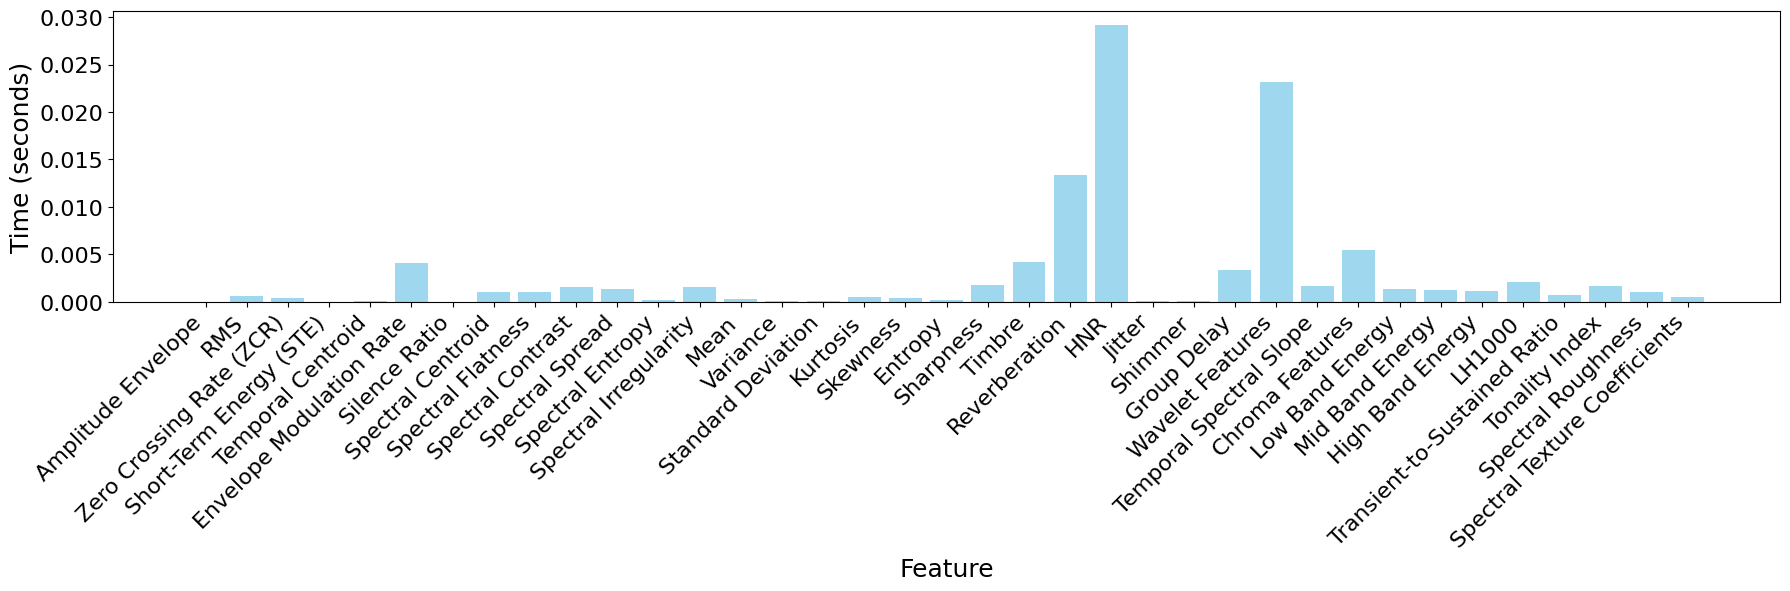

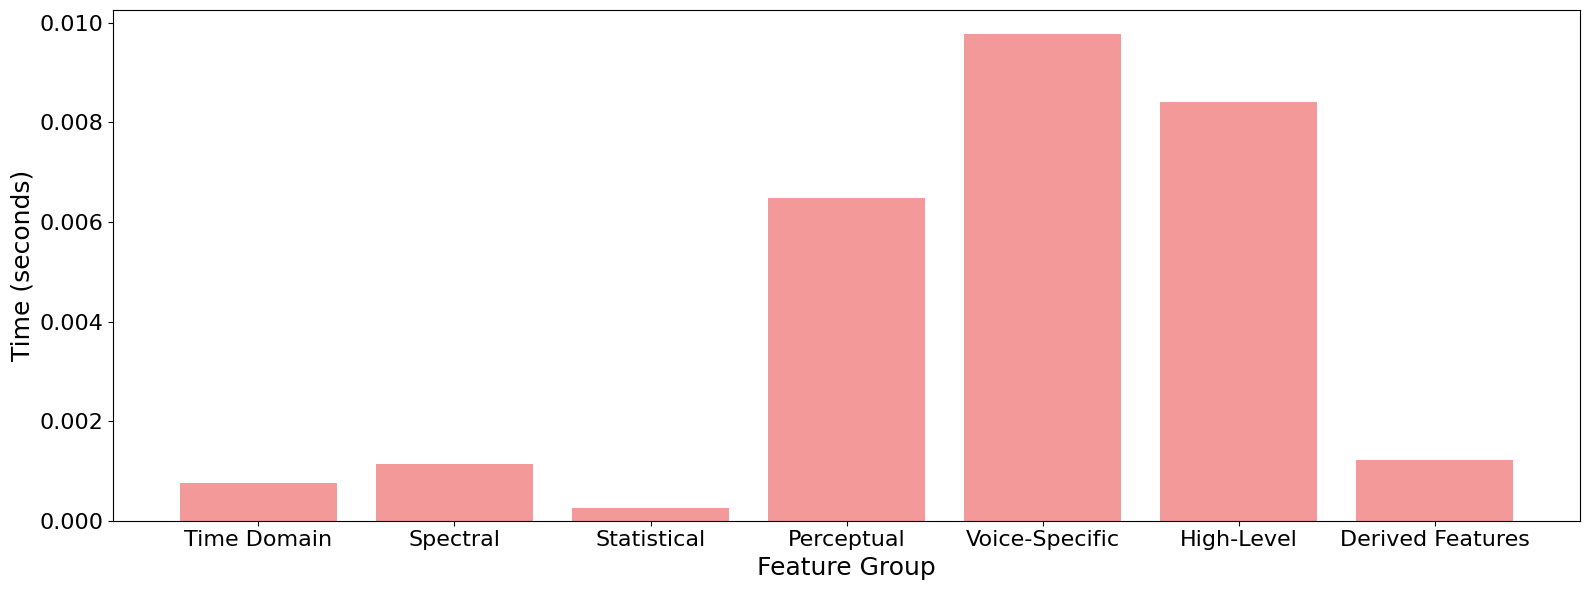

In [23]:
# Example usage
file_path = "example_audio.wav"  # Replace with your audio file path
label = "example_label"
features_df, feature_timing, group_timing = extract_features_with_sliding_window(audio_path, label)

# Plot individual feature extraction times
plt.figure(figsize=(18, 6))
plt.bar(feature_timing.keys(), feature_timing.values(), color='skyblue', alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=16)
# plt.title('Individual Feature Extraction Times')
plt.ylabel('Time (seconds)', fontsize=18)
plt.xlabel('Feature', fontsize=18)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

# Plot group-wise feature extraction times
plt.figure(figsize=(16, 6))
plt.bar(group_timing.keys(), group_timing.values(), color='lightcoral', alpha=0.8)
plt.xticks(rotation=0, fontsize=16)
# plt.title('Group-wise Feature Extraction Times')
plt.ylabel('Time (seconds)', fontsize=18)
plt.xlabel('Feature Group', fontsize=18)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()


In [24]:
feature_timing, group_timing

({'Amplitude Envelope': 1.615285873413086e-05,
  'RMS': 0.000606343150138855,
  'Zero Crossing Rate (ZCR)': 0.00038108229637145996,
  'Short-Term Energy (STE)': 1.8343329429626465e-05,
  'Temporal Centroid': 9.204447269439697e-05,
  'Envelope Modulation Rate': 0.0041157156229019165,
  'Silence Ratio': 2.855062484741211e-05,
  'Spectral Centroid': 0.0010723471641540527,
  'Spectral Flatness': 0.0009906888008117676,
  'Spectral Contrast': 0.0015901178121566772,
  'Spectral Spread': 0.0013836026191711426,
  'Spectral Entropy': 0.00021898746490478516,
  'Spectral Irregularity': 0.0015212297439575195,
  'Mean': 0.00032986700534820557,
  'Variance': 4.652142524719238e-05,
  'Standard Deviation': 4.260241985321045e-05,
  'Kurtosis': 0.00046700239181518555,
  'Skewness': 0.0003894120454788208,
  'Entropy': 0.00022961199283599854,
  'Sharpness': 0.0018174350261688232,
  'Timbre': 0.004226624965667725,
  'Reverberation': 0.013384461402893066,
  'HNR': 0.029180094599723816,
  'Jitter': 6.03944063

In [5]:
from scipy.signal import hilbert
from scipy.fftpack import fft, ifft

def compute_sharpness(fft_spectrum, freqs):
    """
    Compute sharpness using the centroid of the spectrum.
    """
    spectral_centroid = np.sum(freqs * fft_spectrum) / np.sum(fft_spectrum + 1e-12)
    sharpness = spectral_centroid * 0.01
    return sharpness

def compute_timbre(window_segment, sr, num_mfcc=13):
    """
    Compute timbre using an MFCC-like approximation.
    
    Parameters:
        window_segment (numpy.ndarray): The audio signal in the current window.
        sr (int): The sampling rate of the signal.
        num_mfcc (int): Number of MFCC coefficients to calculate.
        
    Returns:
        float: The average MFCC value for the segment.
    """
    # Apply FFT to the window segment
    fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
    log_spectrum = np.log(fft_spectrum + 1e-12)  # Logarithm of the spectrum

    # Create a DCT matrix for the cosine transform
    n_fft = len(log_spectrum)
    dct_matrix = np.cos(np.pi * np.outer(np.arange(num_mfcc), np.arange(n_fft) / n_fft))

    # Compute MFCC-like coefficients
    mfcc = np.dot(dct_matrix, log_spectrum)
    return np.mean(mfcc)


def compute_reverberation(window_segment):
    """
    Compute reverberation using the decay of the energy envelope.
    """
    analytic_signal = hilbert(window_segment)
    envelope = np.abs(analytic_signal)
    reverberation = np.mean(envelope)
    return reverberation

def compute_pitch(window_segment, sr):
    """
    Approximate pitch using the fundamental frequency from FFT.
    """
    fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
    freqs = np.fft.fftfreq(len(window_segment), d=1/sr)[:len(window_segment) // 2]
    fundamental_freq = freqs[np.argmax(fft_spectrum)]
    return fundamental_freq

def compute_hnr(window_segment):
    """
    Compute Harmonics-to-Noise Ratio (HNR).
    """
    analytic_signal = hilbert(window_segment)
    harmonic_energy = np.sum(np.abs(analytic_signal)**2)
    noise_energy = np.sum((window_segment - np.real(analytic_signal))**2)
    hnr = 10 * np.log10(harmonic_energy / (noise_energy + 1e-12))
    return hnr

def compute_jitter(window_segment):
    """
    Compute jitter as the variance of the differences in amplitudes.
    """
    return np.var(np.diff(window_segment))

def compute_shimmer(window_segment):
    """
    Compute shimmer as the mean of the absolute differences in amplitudes.
    """
    return np.mean(np.abs(np.diff(window_segment)))

def compute_group_delay(fft_spectrum):
    """
    Compute group delay from the FFT phase.
    """
    phase = np.angle(fft_spectrum)
    group_delay = -np.diff(phase) / (2.0 * np.pi)
    return np.mean(group_delay)

def compute_wavelet_features(window_segment):
    """
    Compute wavelet features as an example using FFT (simplified).
    """
    fft_spectrum = np.abs(fft(window_segment))
    wavelet_energy = np.sum(fft_spectrum)
    return wavelet_energy

def compute_temporal_spectral_slope(spectral_centroids):
    """
    Compute temporal spectral slope as the mean of differences in spectral centroids.
    """
    return np.mean(np.diff(spectral_centroids))

def compute_band_energy(fft_spectrum, freqs, band_low, band_high):
    """
    Compute energy for a specific frequency band.
    """
    band_energy = np.sum(fft_spectrum[(freqs >= band_low) & (freqs < band_high)])
    return band_energy


In [32]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, stft, hilbert
from scipy.fftpack import fft
from scipy.stats import kurtosis, skew
import time
import matplotlib.pyplot as plt
audio_path = audio_path_prefix+'1-100032-A-0.wav'

def compute_chroma_simple(window_segment, sr, num_bins=12):
    """
    Compute simplified chroma features for a given window segment.

    Parameters:
        window_segment (numpy.ndarray): The audio signal in the current window.
        sr (int): Sampling rate of the signal.
        num_bins (int): Number of chroma bins (typically 12 for 12 semitones).

    Returns:
        float: The average value of chroma features for the window.
    """
    # Compute FFT of the window segment
    fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
    freqs = np.fft.fftfreq(len(window_segment), d=1/sr)[:len(window_segment) // 2]

    # Filter out DC and very low frequencies
    valid_indices = freqs > 0
    freqs = freqs[valid_indices]
    fft_spectrum = fft_spectrum[valid_indices]

    # Map frequencies to chroma bins
    chroma_indices = (np.round(num_bins * np.log2(freqs / 440.0)) % num_bins).astype(int)
    chroma_bins = np.bincount(chroma_indices, weights=fft_spectrum, minlength=num_bins)

    # Normalize chroma bins
    chroma_bins /= np.sum(chroma_bins) + 1e-12

    # Return the mean of chroma bins
    return np.mean(chroma_bins)



# Function for Spectral Roughness
def compute_spectral_roughness(y, sr):
    stft = np.abs(fft(y))[:len(y) // 2]
    freqs = np.fft.fftfreq(len(y), d=1/sr)[:len(y) // 2]
    roughness = np.sum(np.abs(np.diff(stft, axis=0)), axis=0)
    return np.mean(roughness)

# Function for Tonality Index
def compute_tonality_index(y, sr):
    # stft = np.abs(librosa.stft(y))
    stft = np.abs(fft(y))[:len(y) // 2]
    harmonic_energy = np.sum(stft[stft > np.mean(stft)])
    noise_energy = np.sum(stft[stft <= np.mean(stft)])
    return harmonic_energy / (noise_energy + 1e-12)

# Function for Spectral Texture Coefficients
def compute_spectral_texture(y, wavelet='db4', level=4):
    import pywt
    coeffs = pywt.wavedec(y, wavelet, level=level)
    texture_features = [np.std(c) for c in coeffs]
    return np.mean(texture_features)

# Function for Transient-to-Sustained Ratio
def compute_transient_sustained_ratio(y, sr, threshold=0.01):
    # energy = librosa.feature.rms(y=y)
    energy = np.sqrt(np.mean(y ** 2))
    transient_energy = np.sum(energy[energy > threshold])
    sustained_energy = np.sum(energy[energy <= threshold])
    return transient_energy / (sustained_energy + 1e-12)


def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    from scipy.io import wavfile
    sr, y = wavfile.read(file_path)

    # Ensure audio is mono
    if len(y.shape) > 1:
        y = np.mean(y, axis=1)

    # Normalize audio
    y = y / np.max(np.abs(y))

    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)

    # Initialize list to store extracted features
    all_features = []
    feature_timing = {}

    # # Feature groups
    # feature_groups = {
    #     'Time Domain Features': [
    #         'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 'Peak Value',
    #         'Short-Term Energy (STE)', 'Temporal Centroid',
    #         'Envelope Modulation Rate', 'Silence Ratio'
    #     ],
    #     'Spectral Features': [
    #         'Spectral Centroid', 'Spectral Flatness', 'Spectral Contrast',
    #         'Spectral Spread', 'Spectral Entropy', 'Spectral Irregularity', 'Chroma Features'
          
    #     ],
    #     'Statistical Features': [
    #         'Mean', 'Variance', 'Standard Deviation', 'Kurtosis', 'Skewness', 'Entropy'
    #     ],
    #     'Perceptual Features': [
    #         'Sharpness', 'Timbre', 'Reverberation'
    #     ],
    #     'Voice-Specific Features': [
    #         'Pitch', 'HNR', 'Jitter', 'Shimmer'
    #     ],
    #     'High-Level Features (Time-Frequency)': [
    #         'Group Delay', 'Wavelet Features', 'Temporal Spectral Slope'
    #     ],
    #     'Derived Features': [
    #         'Low Band Energy', 'Mid Band Energy', 'High Band Energy', 'LH1000'
    #     ]
    # }

    # feature_groups = {
    #     'Time Domain': [
    #         'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 
    #         'Short-Term Energy (STE)', 'Temporal Centroid',
    #         'Envelope Modulation Rate', 'Silence Ratio'
    #     ],
    #     'Spectral': [
    #         'Spectral Centroid', 'Spectral Flatness', 'Spectral Contrast',
    #         'Spectral Spread', 'Spectral Entropy', 'Chroma Features',
    #         'Spectral Irregularity'
    #     ],
    #     'Statistical': [
    #         'Mean', 'Variance', 'Standard Deviation', 'Kurtosis', 'Skewness', 'Entropy'
    #     ],
    #     'Perceptual': [
    #         'Sharpness', 'Timbre', 'Reverberation'
    #     ],
    #     'Voice-Specific': [
    #         'Pitch', 'HNR', 'Jitter', 'Shimmer'
    #     ],
    #     'High-Level': [
    #         'Group Delay', 'Wavelet Features', 'Temporal Spectral Slope'
    #     ],
    #     'Derived': [
    #         'Low Band Energy', 'Mid Band Energy', 'High Band Energy', 'LH1000'
    #     ]
    # }


    # Feature groups
    feature_groups = {
        'Time Domain': [
            'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 
            'Short-Term Energy (STE)', 'Temporal Centroid',
            'Envelope Modulation Rate', 'Silence Ratio'
        ],
        'Spectral': [
            'Spectral Centroid', 'Spectral Flatness', 'Spectral Contrast',
            'Spectral Spread', 'Spectral Entropy', 
            'Spectral Irregularity'
        ],
        'Statistical': [
            'Mean', 'Variance', 'Standard Deviation', 'Kurtosis', 'Skewness', 'Entropy'
        ],
        'Perceptual': [
            'Sharpness', 'Timbre', 'Reverberation'
        ],
        'Voice-Specific': [
             'HNR', 'Jitter', 'Shimmer'
        ],
        'High-Level': [
            'Group Delay', 'Wavelet Features', 'Temporal Spectral Slope', 'Chroma Features',
        ],
        'Derived Features': [
        'Low Band Energy', 'Mid Band Energy', 'High Band Energy', 'LH1000',
        'Transient-to-Sustained Ratio', 'Tonality Index', 'Spectral Roughness',
        'Spectral Texture Coefficients'
    ]
    }
    
    # Initialize timing dictionary
    for group, features in feature_groups.items():
        for feature in features:
            feature_timing[feature] = 0

    # Sliding window over the audio signal
    x = 0
    for start in range(0, len(y) - window_length + 1, hop_length):
        x+=1
        print(x)
        
        window_segment = y[start:start + window_length]
        features = {}

        # Time Domain Features
        start_time = time.time()
        features['Amplitude Envelope'] = np.max(np.abs(window_segment))
        feature_timing['Amplitude Envelope'] += time.time() - start_time

        start_time = time.time()
        features['RMS'] = np.sqrt(np.mean(window_segment ** 2))
        feature_timing['RMS'] += time.time() - start_time

        start_time = time.time()
        features['Zero Crossing Rate (ZCR)'] = ((window_segment[:-1] * window_segment[1:]) < 0).sum() / len(window_segment)
        feature_timing['Zero Crossing Rate (ZCR)'] += time.time() - start_time

        # start_time = time.time()
        # features['Peak Value'] = np.max(np.abs(window_segment))
        # feature_timing['Peak Value'] += time.time() - start_time

        start_time = time.time()
        features['Short-Term Energy (STE)'] = np.sum(window_segment ** 2)
        feature_timing['Short-Term Energy (STE)'] += time.time() - start_time

        start_time = time.time()
        temporal_indices = np.arange(len(window_segment))
        features['Temporal Centroid'] = np.sum(temporal_indices * (window_segment ** 2)) / np.sum(window_segment ** 2)
        feature_timing['Temporal Centroid'] += time.time() - start_time

        start_time = time.time()
        envelope = np.abs(window_segment)

        # Compute the modulation rate as the mean absolute difference of the envelope
        modulation_rate = np.mean(np.abs(np.diff(envelope)))
        features['Envelope Modulation Rate'] = modulation_rate
        feature_timing['Envelope Modulation Rate'] += time.time() - start_time

        start_time = time.time()
        features['Silence Ratio'] = np.sum(np.abs(window_segment) < 0.01) / len(window_segment)
        feature_timing['Silence Ratio'] += time.time() - start_time

        # Spectral Features
        start_time = time.time()
        fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
        freqs = np.fft.fftfreq(len(window_segment), d=1/sr)[:len(window_segment) // 2]

        features['Spectral Centroid'] = np.sum(freqs * fft_spectrum) / np.sum(fft_spectrum)
        feature_timing['Spectral Centroid'] += time.time() - start_time

        start_time = time.time()
        fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
        features['Spectral Flatness'] = np.exp(np.mean(np.log(fft_spectrum + 1e-12))) / np.mean(fft_spectrum)
        feature_timing['Spectral Flatness'] += time.time() - start_time

        start_time = time.time()
        # features['Chroma Features'] = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()
        features['Chroma Features'] = compute_chroma_simple(window_segment, sr)
        feature_timing['Chroma Features'] += time.time() - start_time

        start_time = time.time()
        fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
        spectral_contrast_peaks = find_peaks(fft_spectrum)[0]
        features['Spectral Contrast'] = np.std(fft_spectrum[spectral_contrast_peaks]) if len(spectral_contrast_peaks) > 0 else 0
        feature_timing['Spectral Contrast'] += time.time() - start_time

        start_time = time.time()
        fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
        freqs = np.fft.fftfreq(len(window_segment), d=1/sr)[:len(window_segment) // 2]
        features['Spectral Spread'] = np.sqrt(np.sum((freqs - features['Spectral Centroid'])**2 * fft_spectrum) / np.sum(fft_spectrum))
        feature_timing['Spectral Spread'] += time.time() - start_time

        start_time = time.time()
        fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
        features['Spectral Entropy'] = -np.sum((fft_spectrum / np.sum(fft_spectrum)) * np.log2(fft_spectrum / np.sum(fft_spectrum) + 1e-12))
        feature_timing['Spectral Entropy'] += time.time() - start_time

        start_time = time.time()
        fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
        features['Spectral Irregularity'] = np.std(np.diff(fft_spectrum))
        feature_timing['Spectral Irregularity'] += time.time() - start_time

        # start_time = time.time()
        # features['Spectral Skewness'] = skew(fft_spectrum)
        # feature_timing['Spectral Skewness'] += time.time() - start_time

        # start_time = time.time()
        # features['Spectral Kurtosis'] = kurtosis(fft_spectrum)
        # feature_timing['Spectral Kurtosis'] += time.time() - start_time

        # Statistical Features
        start_time = time.time()
        features['Mean'] = np.mean(window_segment)
        feature_timing['Mean'] += time.time() - start_time

        start_time = time.time()
        features['Variance'] = np.var(window_segment)
        feature_timing['Variance'] += time.time() - start_time

        start_time = time.time()
        features['Standard Deviation'] = np.std(window_segment)
        feature_timing['Standard Deviation'] += time.time() - start_time

        start_time = time.time()
        features['Kurtosis'] = kurtosis(window_segment)
        feature_timing['Kurtosis'] += time.time() - start_time

        start_time = time.time()
        features['Skewness'] = skew(window_segment)
        feature_timing['Skewness'] += time.time() - start_time

        start_time = time.time()
        features['Entropy'] = -np.sum(window_segment * np.log2(window_segment + 1e-12))
        feature_timing['Entropy'] += time.time() - start_time

        # Perceptual Features
        start_time = time.time()
        fft_spectrum = np.abs(fft(window_segment))[:len(window_segment) // 2]
        freqs = np.fft.fftfreq(len(window_segment), d=1/sr)[:len(window_segment) // 2]
        
        features['Sharpness'] = compute_sharpness(fft_spectrum, freqs)
        feature_timing['Sharpness'] += time.time() - start_time
        
        start_time = time.time()
        features['Timbre'] = compute_timbre(window_segment, sr)
        feature_timing['Timbre'] += time.time() - start_time
        
        start_time = time.time()
        features['Reverberation'] = compute_reverberation(window_segment)
        feature_timing['Reverberation'] += time.time() - start_time
        
        # # Voice-Specific Features
        # start_time = time.time()
        # features['Pitch'] = compute_pitch(window_segment, sr)
        # feature_timing['Pitch'] += time.time() - start_time
        
        start_time = time.time()
        features['HNR'] = compute_hnr(window_segment)
        feature_timing['HNR'] += time.time() - start_time
        
        start_time = time.time()
        features['Jitter'] = compute_jitter(window_segment)
        feature_timing['Jitter'] += time.time() - start_time
        
        start_time = time.time()
        features['Shimmer'] = compute_shimmer(window_segment)
        feature_timing['Shimmer'] += time.time() - start_time
        
        # High-Level Features
        start_time = time.time()
        features['Group Delay'] = compute_group_delay(fft_spectrum)
        feature_timing['Group Delay'] += time.time() - start_time
        
        start_time = time.time()
        features['Wavelet Features'] = compute_wavelet_features(window_segment)
        feature_timing['Wavelet Features'] += time.time() - start_time
        
        start_time = time.time()
        spectral_centroids = np.sum(freqs * fft_spectrum) / np.sum(fft_spectrum)
        features['Temporal Spectral Slope'] = compute_temporal_spectral_slope([spectral_centroids])
        feature_timing['Temporal Spectral Slope'] += time.time() - start_time
        
        # Derived Features
        start_time = time.time()
        features['Low Band Energy'] = compute_band_energy(fft_spectrum, freqs, 0, 500)
        feature_timing['Low Band Energy'] += time.time() - start_time
        
        start_time = time.time()
        features['Mid Band Energy'] = compute_band_energy(fft_spectrum, freqs, 500, 2000)
        feature_timing['Mid Band Energy'] += time.time() - start_time
        
        start_time = time.time()
        features['High Band Energy'] = compute_band_energy(fft_spectrum, freqs, 2000, max(freqs))
        feature_timing['High Band Energy'] += time.time() - start_time

        start_time = time.time()
        features['Low Band Energy'] = compute_band_energy(fft_spectrum, freqs, 0, 500)
        features['High Band Energy'] = compute_band_energy(fft_spectrum, freqs, 2000, max(freqs))

        features['LH1000'] = features['Low Band Energy'] / (features['High Band Energy'] + 1e-12)
        feature_timing['LH1000'] += time.time() - start_time

        start_time = time.time()
        features['Transient-to-Sustained Ratio'] = compute_transient_sustained_ratio(window_segment, sr)
        feature_timing['Transient-to-Sustained Ratio'] += time.time() - start_time
        start_time = time.time()
        features['Tonality Index'] = compute_tonality_index(window_segment, sr)
        feature_timing['Tonality Index'] += time.time() - start_time
        start_time = time.time()
        features['Spectral Roughness'] = compute_spectral_roughness(window_segment, sr)
        feature_timing['Spectral Roughness'] += time.time() - start_time
        start_time = time.time()
        features['Spectral Texture Coefficients'] = compute_spectral_texture(window_segment)
        feature_timing['Spectral Texture Coefficients'] += time.time() - start_time

        # Add window index to features
        # features['Window Index'] = start // hop_length
        features['Label'] = label

        # Append features for this window
        all_features.append(features)
        

    # Convert list of features to a DataFrame
    df = pd.DataFrame(all_features)

    num_windows = 16  # Total number of windows
    average_feature_timing = {feature: total_time / num_windows for feature, total_time in feature_timing.items()}


    # Calculate average timing by group
    group_timing = {
        group: (sum(average_feature_timing[feature] for feature in features) / len(features))
        for group, features in feature_groups.items()
    }

    return df, average_feature_timing, group_timing


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_4596/1944011733.py:220: RuntimeWarning: invalid value encountered in scalar divide
  features['Temporal Centroid'] = np.sum(temporal_indices * (window_segment ** 2)) / np.sum(window_segment ** 2)
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_4596/1944011733.py:240: RuntimeWarning: invalid value encountered in scalar divide
  features['Spectral Centroid'] = np.sum(freqs * fft_spectrum) / np.sum(fft_spectrum)
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_4596/1944011733.py:245: RuntimeWarning: divide by zero encountered in scalar divide
  features['Spectral Flatness'] = np.exp(np.mean(np.log(fft_spectrum + 1e-12))) / np.mean(fft_spectrum)
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_4596/1944011733.py:267: RuntimeWarning: invalid value encountered in divide
  features['Spectral Entropy'] = -np.sum((fft_spectrum / np.sum(fft_spectrum)) * np.log2(fft_spectrum / np.sum(fft_spectrum) + 1e-12))


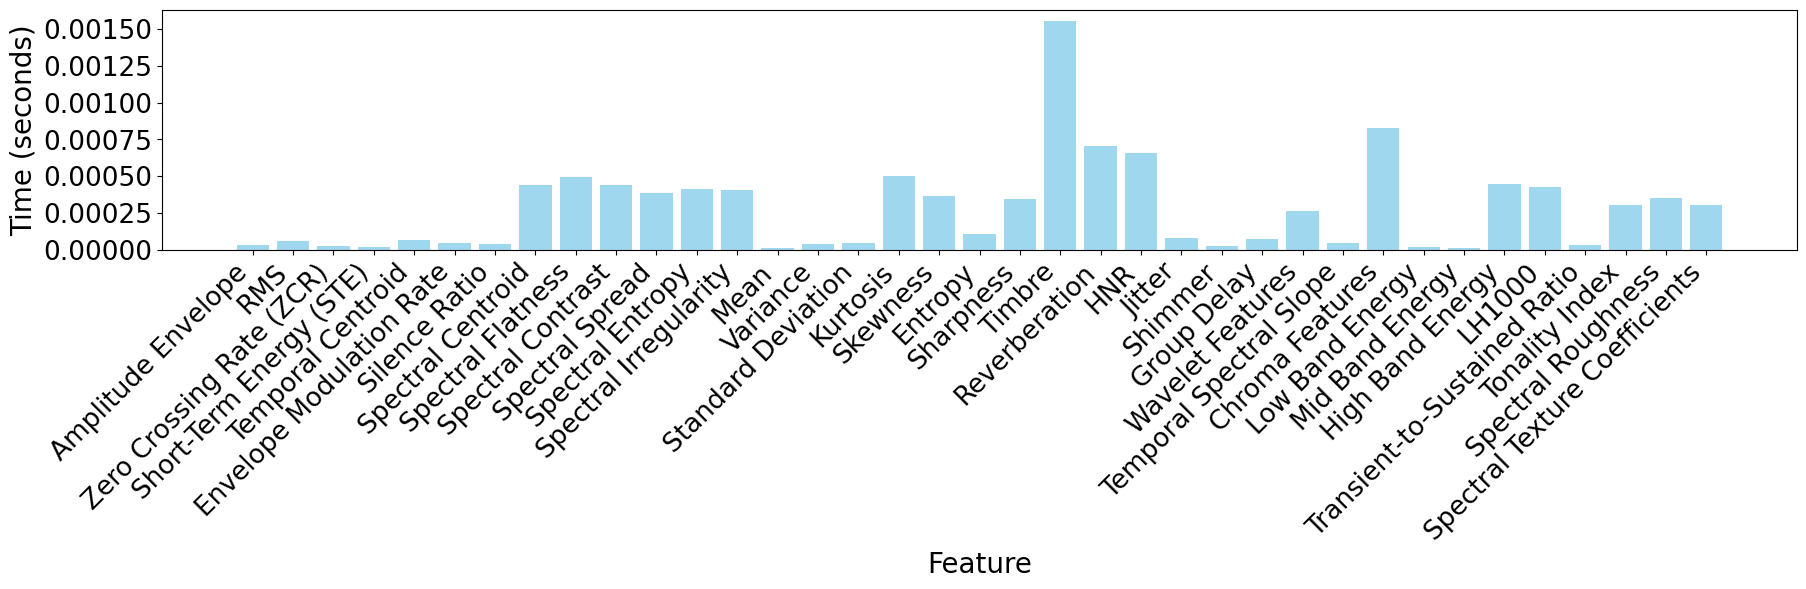

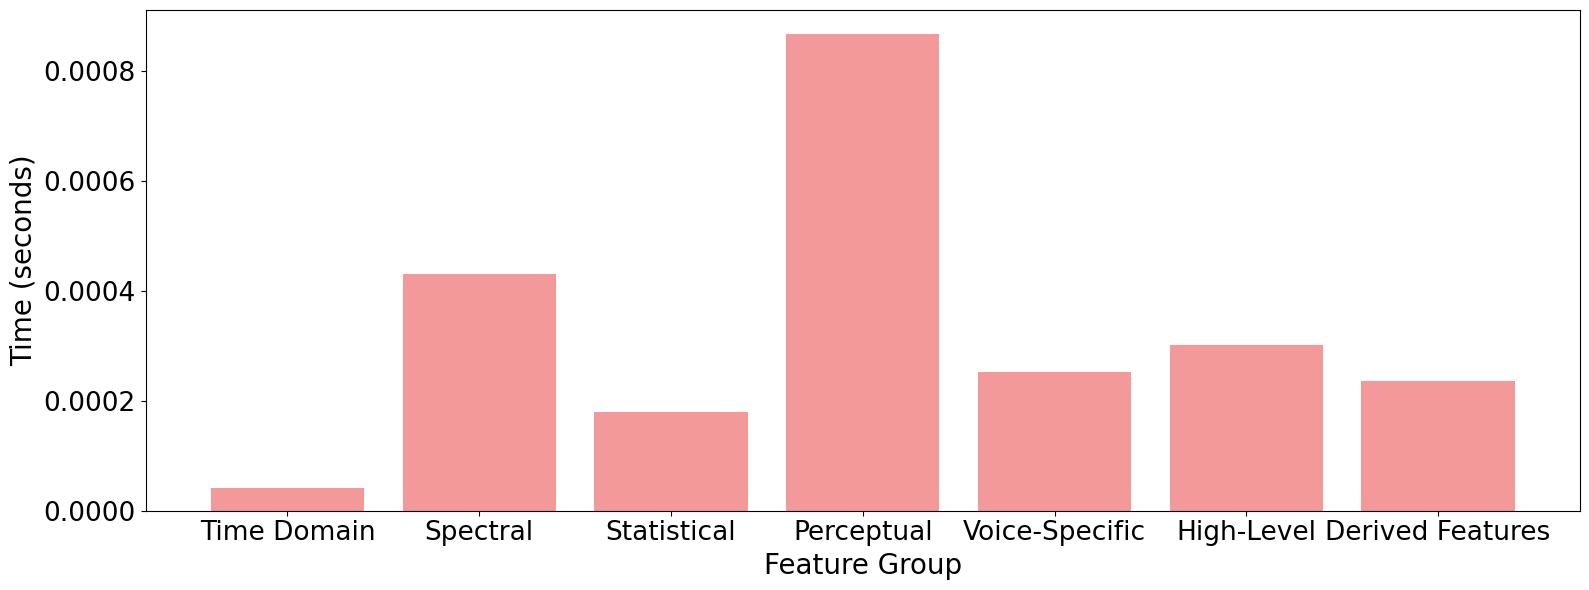

In [36]:
# Example usage
file_path = "example_audio.wav"  # Replace with your audio file path
label = "example_label"
features_df, feature_timing, group_timing = extract_features_with_sliding_window(audio_path, label)



# Compute average timing for each feature


# Plot individual feature extraction times
plt.figure(figsize=(18, 6))
plt.bar(feature_timing.keys(), feature_timing.values(), color='skyblue', alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=19)
# plt.title('Individual Feature Extraction Times')
plt.ylabel('Time (seconds)', fontsize=20)
plt.xlabel('Feature', fontsize=20)
plt.yticks(fontsize=19)
plt.tight_layout()
plt.savefig('optimized_times_individual_feature2.png')
plt.show()

# Plot group-wise feature extraction times
plt.figure(figsize=(16, 6))
plt.bar(group_timing.keys(), group_timing.values(), color='lightcoral', alpha=0.8)
plt.xticks(rotation=0, fontsize=19)
# plt.title('Group-wise Feature Extraction Times')
plt.ylabel('Time (seconds)', fontsize=20)
plt.xlabel('Feature Group', fontsize=20)
plt.yticks(fontsize=19)
plt.tight_layout()
plt.show()


In [34]:
feature_timing, group_timing

({'Amplitude Envelope': 3.53008508682251e-05,
  'RMS': 2.6747584342956543e-05,
  'Zero Crossing Rate (ZCR)': 3.0174851417541504e-05,
  'Short-Term Energy (STE)': 1.691281795501709e-05,
  'Temporal Centroid': 7.320940494537354e-05,
  'Envelope Modulation Rate': 5.373358726501465e-05,
  'Silence Ratio': 2.199411392211914e-05,
  'Spectral Centroid': 0.0003828108310699463,
  'Spectral Flatness': 0.00044132769107818604,
  'Spectral Contrast': 0.0003697127103805542,
  'Spectral Spread': 0.00038421154022216797,
  'Spectral Entropy': 0.0003636479377746582,
  'Spectral Irregularity': 0.0003350973129272461,
  'Mean': 1.1473894119262695e-05,
  'Variance': 3.583729267120361e-05,
  'Standard Deviation': 3.5375356674194336e-05,
  'Kurtosis': 0.0004332512617111206,
  'Skewness': 0.0003771781921386719,
  'Entropy': 0.00011053681373596191,
  'Sharpness': 0.000325813889503479,
  'Timbre': 0.0012444108724594116,
  'Reverberation': 0.0006265789270401001,
  'HNR': 0.0006097257137298584,
  'Jitter': 6.86198

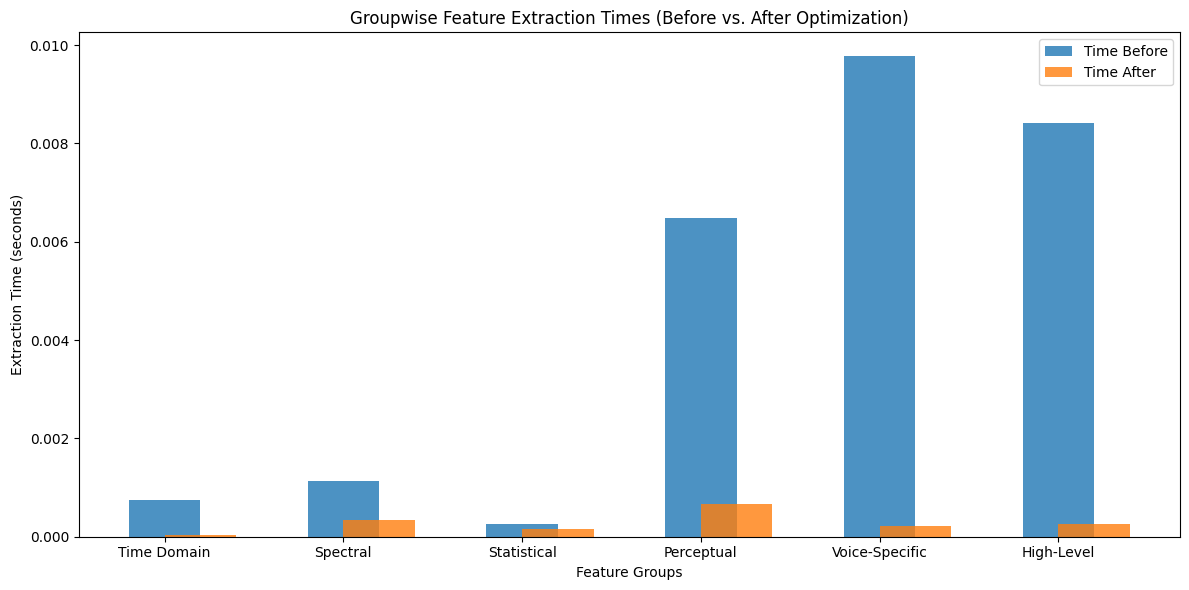

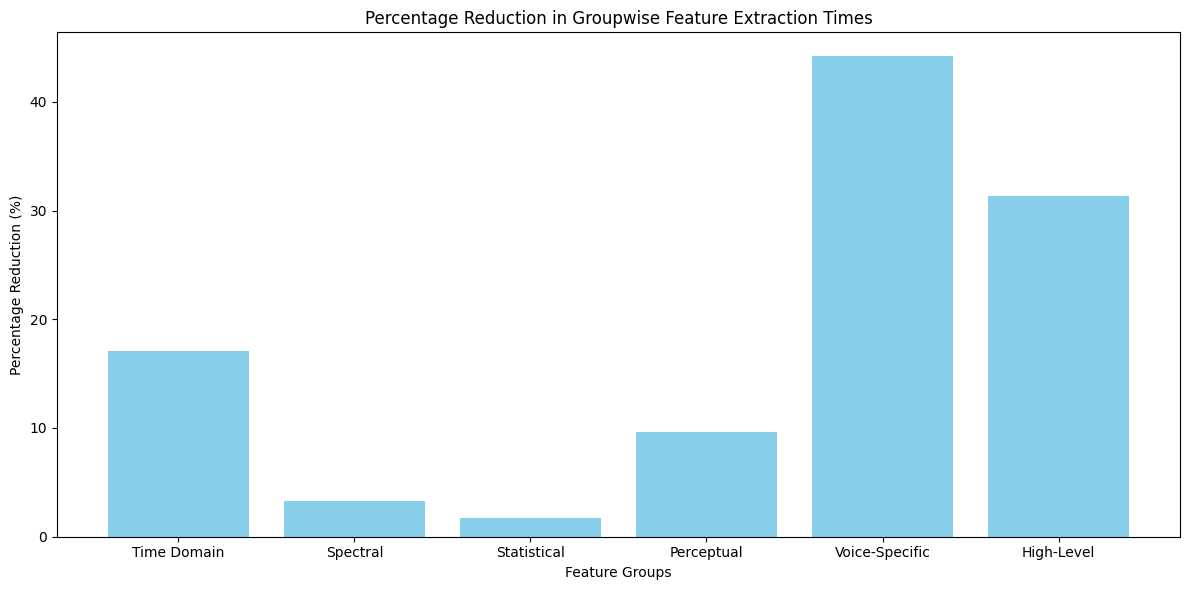

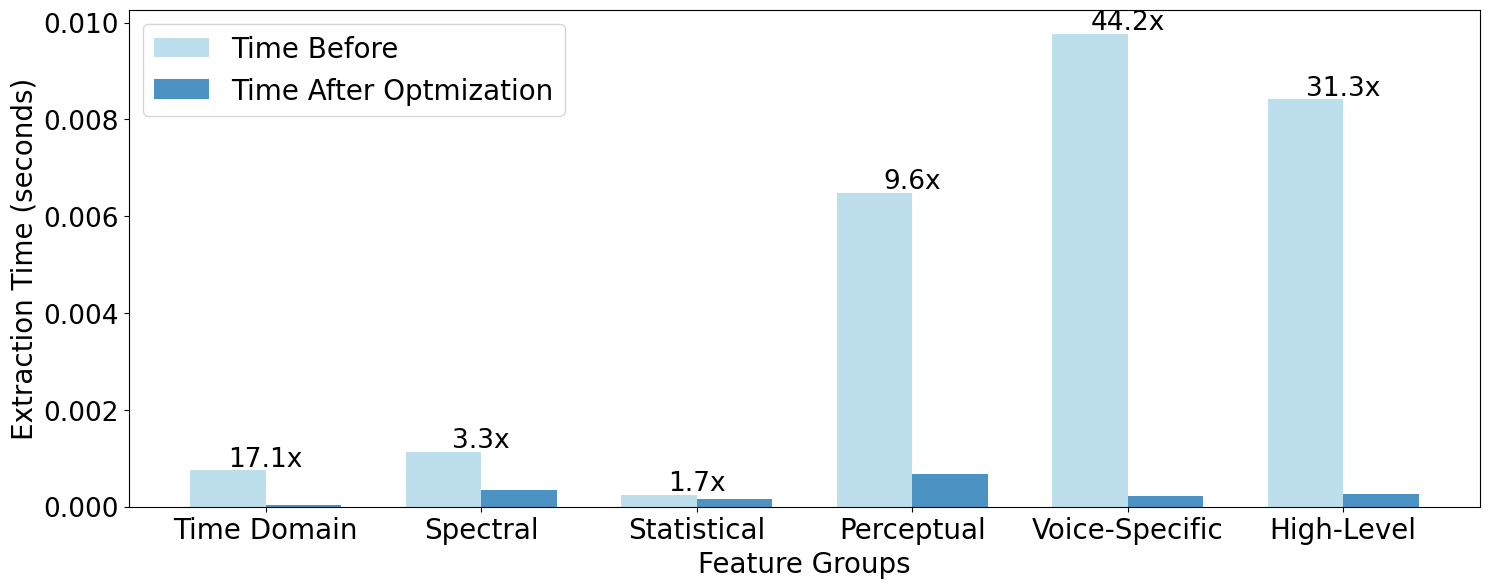

In [26]:

import matplotlib.pyplot as plt
# Updated groupwise results before and after optimization
groupwise_before = {
    'Time Domain': 0.002247222832271031,
    'Spectral': 0.0017058146851403372,
    'Statistical': 0.00035311530033747357,
    'Perceptual': 0.007248938083648682,
    'Voice-Specific': 0.00862804800271988,
    'High-Level': 0.0125314990679423,
    'Derived': 0.0015546977519989014
}

groupwise_after = {
    'Time Domain': 4.3526291847229004e-05,
    'Spectral': 0.0004734907831464495,
    'Statistical': 0.00020080556472142538,
    'Perceptual': 0.0009388476610183716,
    'Voice-Specific': 0.0002739056944847107,
    'High-Level': 0.00013944009939829508,
    'Derived': 0.00023203343152999878
}


groupwise_before = {'Time Domain': 0.000751176050731114,
  'Spectral': 0.0011294956008593242,
  'Statistical': 0.00025083621342976886,
  'Perceptual': 0.006476173798243205,
  'Voice-Specific': 0.009770572185516357,
  'High-Level': 0.008411575108766556,
  'Derived Features': 0.0012247860431671143}

groupwise_after = {'Time Domain': 4.4035060065133234e-05,
  'Spectral': 0.00034363816181818646,
  'Statistical': 0.00014925003051757812,
  'Perceptual': 0.0006717145442962646,
  'Voice-Specific': 0.00022115806738535562,
  'High-Level': 0.0002686344087123871,
  'Derived': 0.00025035813450813293}

# Convert to DataFrame
df_groupwise_before = pd.DataFrame(list(groupwise_before.items()), columns=['Group', 'Time Before'])
df_groupwise_after = pd.DataFrame(list(groupwise_after.items()), columns=['Group', 'Time After'])

# Merge the two DataFrames
df_groupwise = pd.merge(df_groupwise_before, df_groupwise_after, on='Group')

# Calculate percentage reduction
df_groupwise['Reduction (%)'] = ((df_groupwise['Time Before'] - df_groupwise['Time After']) / df_groupwise['Time Before']) * 100

df_groupwise['Reduction (%)'] = df_groupwise['Time Before'] /df_groupwise['Time After']


# Plot groupwise results
plt.figure(figsize=(12, 6))
plt.bar(df_groupwise['Group'], df_groupwise['Time Before'], width=0.4, label='Time Before', align='center', alpha=0.8)
plt.bar(df_groupwise['Group'], df_groupwise['Time After'], width=0.4, label='Time After', align='edge', alpha=0.8)
plt.xlabel('Feature Groups')
plt.ylabel('Extraction Time (seconds)')
plt.title('Groupwise Feature Extraction Times (Before vs. After Optimization)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot percentage reduction
plt.figure(figsize=(12, 6))
plt.bar(df_groupwise['Group'], df_groupwise['Reduction (%)'], color='skyblue')
plt.xlabel('Feature Groups')
plt.ylabel('Percentage Reduction (%)')
plt.title('Percentage Reduction in Groupwise Feature Extraction Times')
plt.tight_layout()
plt.show()



# Adjust plot settings as per the updated requirements
plt.figure(figsize=(15, 6))
bar_width = 0.35
x = np.arange(len(df_groupwise['Group']))

# Bars for "Time Before" and "Time After"
plt.bar(x - bar_width/2, df_groupwise['Time Before'], width=bar_width, label='Time Before', alpha=0.8, color = 'lightblue')
plt.bar(x + bar_width/2, df_groupwise['Time After'], width=bar_width, label='Time After Optmization', alpha=0.8)

# Annotations for percentage reduction
for i, row in df_groupwise.iterrows():
    plt.text(x[i], max(row['Time Before'], row['Time After']) + 0.00009,
             f"{row['Reduction (%)']:.1f}x", ha='center', fontsize=19, color='black')

# Customize plot
plt.xticks(x, df_groupwise['Group'], fontsize=20)
plt.yticks( fontsize=19)

plt.xlabel('Feature Groups', fontsize=20)
plt.ylabel('Extraction Time (seconds)', fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig('time_before_after2_updated.png')
plt.show()



In [32]:
(3.102421760559082e-05 - 0.0012)/ 0.0012

-0.9741464853286743

NameError: name 'top_10_latency_features' is not defined

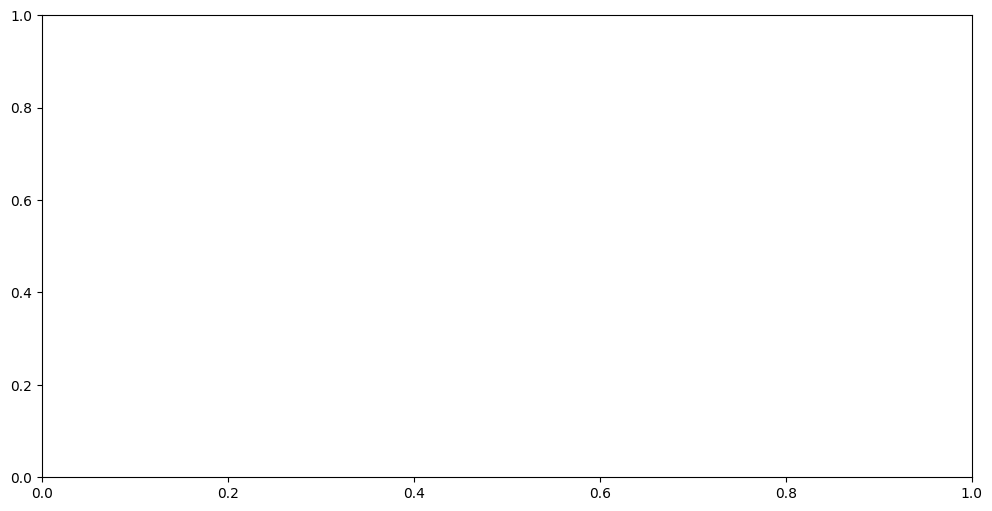

In [28]:
# Generate a single bar graph with correct tick formatting
fig, ax = plt.subplots(figsize=(12, 6))

# Define color for better visualization
color = "#ff7f0e"  # Orange

# Plot the top 10 highest latency features
bars = ax.barh(top_10_latency_features.index, top_10_latency_features['Latency'], color=color)

# Annotate latency values
for bar in bars:
    ax.text(bar.get_width() + 0.00001, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.5f}s", va='center', fontsize=16, color='black')

# Increase font sizes for readability
ax.set_xlabel("Feature Extraction Time (seconds)", fontsize=22)
ax.set_ylabel("Feature", fontsize=22)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticks(), fontsize=20)
ax.set_yticklabels(top_10_latency_features.index, fontsize=20)

plt.show()
